# Dusty Red Galaxies in COSMOS-Web
AP 2026

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy
from utilities.cosmosWebHandler import CosmosWebHandler
from utilities.jadesHandler import JadesHandler
from utilities.catalogHandler import CatalogHandler

from astropy.table import Table
from astropy.io import fits
from utilities.almaA3Handler import AlmaA3Handler
from utilities.champsHandler import ChampsHandler
from utilities.mighteeHandler import MighteeHandler
from utilities.superDeblendedHandler import SuperDeblendedHandler
from utilities.jadesApertureEnum import JadesApertureEnum
from utilities.cosmosWebApertureEnum import CosmosWebApertureEnum
from utilities.bandEnum import BandEnum
from utilities.almaSpectraHandler import AlmaSpectraHandler

from utilities.utils import plot_alma_spectra, plot_alma_spectra_with_co_fit, plot_alma_spectra_with_h2o_fit, plot_alma_spectra_with_snr, include_scale_bar, include_interface_box, include_marker_scaled, include_ellipse_scaled, check_point_is_in_image, include_small_crosshair, plot_panel, get_statistics_with_sigma_clipping, get_peak_within_radius

from astropy.wcs import WCS
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
import fitz  # PyMuPDF
import os
from IPython.display import HTML
import pandas as pd

In [14]:
# constants

PATH_PREFIX = '/Volumes/Apple SDXC Reader Media/dusty-red'
# PATH_PREFIX = '/scratch/poulin.al/dawn'

CATALOG_PATH = f"{PATH_PREFIX}/data/COSMOSWeb_mastercatalog_v1.1.fits"
# CATALOG_LIGHT_PATH = f'{PATH_PREFIX}/data/COSMOSWeb_mastercatalog_v1.1_no_cigale_no_bd_no_ml_morpho_no_se_aper_no_galfitm_morpho.fits'  # a lighter version of the catalog with the cigale, bd, ml-morpho, se_aper, and galfitm-morpho columns removed to save space and load time, since we won't be using those columns in our analysis
CATALOG_LIGHTER_PATH = f'{PATH_PREFIX}/data/COSMOSWeb_mastercatalog_v1.1_no_cigale_no_bd_no_ml_morpho_no_se_aper_no_galfitm_morpho_lightphotom.fits'  # an even lighter version of the catalog with only the photometric columns (and the id, ra, dec columns) included, for quick loading when we only need the photometric data and not the lephare/cigale/bd/ml-morpho/se_aper/galfitm-morpho data
# CATALOG_LIGHTEST_PATH = f'{PATH_PREFIX}/data/COSMOSWeb_mastercatalog_v1.1_no_cigale_no_bd_no_ml_morpho_no_se_aper_no_galfitm_morpho_lightphotom_condition_clean_miri.fits'  # an even lighter version of the catalog with only the photometric columns (and the id, ra, dec columns) included, and only the objects that pass the condition_clean_miri cut included, for quick loading when we only need the photometric data for the objects that pass the condition_clean_miri cut.

DATA_DIR    = f'{PATH_PREFIX}/data'   # folder with the tiles
# (old) only needed if viewing the tile images of the catalog objects

CHAMPS_PRELIM_PRIOR_CATALOG = f'{PATH_PREFIX}/data/alma_prelim_catalog/Catalogs/champs_prior_catalog.fits'
CHAMPS_PRELIM_BLIND_CATALOG = f'{PATH_PREFIX}d/data/alma_prelim_catalog/Catalogs/champs_blind_catalog.fits'
CHAMPS_IMAGE_MAP40 = f'{PATH_PREFIX}/data/alma_prelim_catalog/image_maps/champs_full_field_concat_split_pbcorr_40.fits'
CHAMPS_IMAGE_MAP20 = f'{PATH_PREFIX}/data/alma_prelim_catalog/image_maps/champs_full_field_concat_split_pbcorr_20.fits'
CHAMPS_IMAGE_MAP = f'{PATH_PREFIX}/data/alma_prelim_catalog/image_maps/champs_full_field_concat_split_image.fits'

MIGHTEE_CATALOG = f'{PATH_PREFIX}/data/mightee_continuum/MIGHTEE_Continuum_DR1_COSMOS_5p2arcsec_I_v1.1.fits'
L_BAND_IMAGE = f'{PATH_PREFIX}/data/mightee_continuum/COSMOS_XS_VLA_Lband.fits'
S_BAND_IMAGE = f'{PATH_PREFIX}/data/mightee_continuum/COSMOS_XS_VLA_Sband_img.fits'
VLA_3GHZ_IMAGE = f'{PATH_PREFIX}/data/mightee_continuum/vla_3ghz_msmf.fits'

SUPER_DEBLENDED_CATALOG = f'{PATH_PREFIX}/data/super-deblended/COSMOS_deblended_FIR_201821_photo_phys_2023June.fits'


JADES_N_CATALOG_PATH = '/Volumes/Apple SDXC Reader Media/dusty-red/data/jades/hlsp_jades_jwst_nircam_goods-n_photometry_v5.0_catalog.fits'
JADES_N_CATALOG_PATH_LIGHT = '/Volumes/Apple SDXC Reader Media/dusty-red/data/jades/hlsp_jades_jwst_nircam_goods-n_photometry_v5.0_catalog_flags_size_circ-bsub-conv_miri.fits'
JADES_N_CATALOG_PATH_LIGHTER = '/Volumes/Apple SDXC Reader Media/dusty-red/data/jades/hlsp_jades_jwst_nircam_goods-n_photometry_v5.0_catalog_flags_size_circ-bsub-conv_miri_photoz_lighter.fits'
JADES_S_CATALOG_PATH = '/Volumes/Apple SDXC Reader Media/dusty-red/data/jades/hlsp_jades_jwst_nircam_goods-s_photometry_v5.0_catalog.fits'
JADES_S_CATALOG_PATH_LIGHT = '/Volumes/Apple SDXC Reader Media/dusty-red/data/jades/hlsp_jades_jwst_nircam_goods-s_photometry_v5.0_catalog_flags_size_circ-bsub-conv_miri.fits'
JADES_S_CATALOG_PATH_LIGHTER = '/Volumes/Apple SDXC Reader Media/dusty-red/data/jades/hlsp_jades_jwst_nircam_goods-s_photometry_v5.0_catalog_flags_size_circ-bsub-conv_miri_photoz_lighter.fits'


In [15]:
# load the handler
catalogHandler = CosmosWebHandler(CATALOG_LIGHTER_PATH)
catalogHandler.load_catalog(CATALOG_LIGHTER_PATH)
# catalogHandler = CosmosWebHandler(CATALOG_PATH)
# catalogHandler.save_reduced_catalog(CATALOG_LIGHTER_PATH, reduced='lighter')

# catalogHandler = JadesHandler(JADES_N_CATALOG_PATH)
# catalogHandler = JadesHandler(JADES_S_CATALOG_PATH)


# catalogHandler = JadesHandler(JADES_N_CATALOG_PATH_LIGHTER)
# catalogHandler = JadesHandler(JADES_S_CATALOG_PATH_LIGHTER)


# circ_to_use = 'circ' # options are 'circ', 'circ_bsub', 'circ_conv', and 'circ_bsub_conv'.
# if isinstance(catalogHandler, JadesHandler):
#     catalogHandler.load_catalog(circ_to_use=circ_to_use)
# elif isinstance(catalogHandler, CosmosWebHandler):
#     catalogHandler.load_catalog(CATALOG_LIGHTER_PATH)

# catalogHandler.save_reduced_catalog(JADES_N_CATALOG_PATH_LIGHTER, reduced='lighter')

Filename: /Volumes/Apple SDXC Reader Media/dusty-red/data/COSMOSWeb_mastercatalog_v1.1_no_cigale_no_bd_no_ml_morpho_no_se_aper_no_galfitm_morpho_lightphotom.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  PHOTOMETRY    1 BinTableHDU    107   784016R x 49C   [K, D, D, D, D, D, D, K, D, D, 5D, D, 5D, 5D, D, D, 5D, D, 5D, 5D, D, D, 5D, D, 5D, 5D, D, D, 5D, D, 5D, 5D, D, D, 5D, D, 5D, 5D, D, D, D, D, D, D, D, D, D, D, 3A]   
  2  LEPHARE       1 BinTableHDU     13   784016R x 2C   [K, D]   
 HDU Info: None
Catalog loaded successfully. Tables present: photom, lephare
Purity cut: 650707 out of 784016 objects remain. Fraction: 83.00%
MIRI cut: 177816 out of 650707 objects remain. Fraction: 27.33%


### common functions

In [5]:
import requests
pdf_url_sourceid = lambda sid: f"https://cosmos2025.iap.fr/fitsmap/data/inspec_plots/cosmos_web_sed_{sid}.pdf"
_png_cache = {}   # sid -> list of PNG byte-strings (one per page)
def _render_pdf(sid, dpi=130):
    if sid not in _png_cache:
        r = requests.get(pdf_url_sourceid(sid), timeout=30)
        r.raise_for_status()
        doc = fitz.open(stream=r.content, filetype='pdf')
        _png_cache[sid] = [doc.load_page(p).get_pixmap(dpi=dpi).tobytes('png')
                           for p in range(doc.page_count)]
        doc.close()
    return _png_cache[sid]

def _getcol(p, *names):
    if hasattr(p, 'colnames'):
        for n in names:
            if n in p.colnames:
                return np.asarray(p[n])
    if hasattr(p, 'dtype') and p.dtype.names:
        for n in names:
            if n in p.dtype.names:
                return np.asarray(p[n])
    for n in names:
        if n in p:
            return np.asarray(p[n])
    raise KeyError(f"none of {names} found")

## make detection cuts

#### condition detection -- flux aperature

In [9]:
aperature_for_analysis = CosmosWebApertureEnum.APER_0p5.value if isinstance(catalogHandler, CosmosWebHandler) else JadesApertureEnum.APER0.value if isinstance(catalogHandler, JadesHandler) else None

if aperature_for_analysis is None:
    raise NotImplementedError("Aperture for analysis not defined for this catalog handler type.")

print(f"Using aperture {aperature_for_analysis} for analysis.")

Using aperture 2 for analysis.


In [17]:

# aperature_for_analysis = CosmosWebApertureEnum.APER_0p5.value if isinstance(catalogHandler, CosmosWebHandler) else JadesApertureEnum.APER_0p5.value if isinstance(catalogHandler, JadesHandler) else None

# aperature_for_analysis = CosmosWebApertureEnum.APER_0p75.value if isinstance(catalogHandler, CosmosWebHandler) else JadesApertureEnum.APER_0p35.value if isinstance(catalogHandler, JadesHandler) else None

# aperature_for_analysis = CosmosWebApertureEnum.APER_0p3.value if isinstance(catalogHandler, CosmosWebHandler) else JadesApertureEnum.APER_0p3.value if isinstance(catalogHandler, JadesHandler) else None

# aperature_for_analysis = CosmosWebApertureEnum.APER_0p2.value if isinstance(catalogHandler, CosmosWebHandler) else JadesApertureEnum.APER_0p25.value if isinstance(catalogHandler, JadesHandler) else None

# aperature_for_analysis = CosmosWebApertureEnum.APER_0p5.value if isinstance(catalogHandler, CosmosWebHandler) else JadesApertureEnum.APER_0p15.value if isinstance(catalogHandler, JadesHandler) else None

# aperature_for_analysis = CosmosWebApertureEnum.APER_0p5.value if isinstance(catalogHandler, CosmosWebHandler) else JadesApertureEnum.APER_0p1.value if isinstance(catalogHandler, JadesHandler) else None


# catalogHandler.clean_miri_cut(aperature = JadesApertureEnum.APER0.value)
catalogHandler.clean_miri_cut(aperature = aperature_for_analysis)
catalogHandler.make_selection_cut(aperature = aperature_for_analysis, use_image_error=False) if isinstance(catalogHandler, JadesHandler) else catalogHandler.make_selection_cut(aperature = aperature_for_analysis)

if isinstance(catalogHandler, CosmosWebHandler):
    condition_detection_reviewed = catalogHandler.get_filter_cut(filtername='condition_detection_reviewed', filter_func=lambda photom, lephare, cigale, bd: photom['id'] != None, filter_to_take_from='condition_detection_aper')
elif isinstance(catalogHandler, JadesHandler):
    condition_detection_reviewed = catalogHandler.get_filter_cut(filtername='condition_detection_reviewed', filter_func=lambda flag, size, circ, miri, photoz: flag['ID'] != None, filter_to_take_from='condition_detection_aper')
else:
    raise NotImplementedError("condition_detection_reviewed cut not implemented for this catalog handler type.")



MIRI cut: 177816 out of 650707 objects remain. Fraction: 27.33%
Filter cut: 29 out of 177816 objects remain. Fraction: 0.02%
Filter cut: 29 out of 29 objects remain. Fraction: 100.00%


### see detection from inspection plots

#### Cosmos-Web

In [ ]:
# cycle through the 18 detected objects, showing the COSMOS-Web DR1 per-source
# inspection plot (SED) for each via "https://cosmos2025.iap.fr/fitsmap/data/inspec_plots/cosmos_web_sed_{sid}.pdf"
import requests
import fitz  # PyMuPDF
from IPython.display import Image, display
import ipywidgets as widgets

pdf_url_sourceid = lambda sid: f"https://cosmos2025.iap.fr/fitsmap/data/inspec_plots/cosmos_web_sed_{sid}.pdf"

_cat_sed = catalogHandler.get_cat_photom('condition_detection_aper')
_sids = np.asarray(_cat_sed['id'])
# _tiles_sed = np.asarray(_cat_sed['tile']).astype(str)
_n_sed = len(_sids)

_png_cache = {}   # sid -> list of PNG byte-strings (one per page)

def _render_pdf(sid, dpi=130):
    if sid not in _png_cache:
        r = requests.get(pdf_url_sourceid(sid), timeout=30)
        r.raise_for_status()
        doc = fitz.open(stream=r.content, filetype='pdf')
        _png_cache[sid] = [doc.load_page(p).get_pixmap(dpi=dpi).tobytes('png')
                           for p in range(doc.page_count)]
        doc.close()
    return _png_cache[sid]


_slider_sed = widgets.IntSlider(min=0, max=_n_sed - 1, step=1, value=0, description='object')
_prev_sed = widgets.Button(description='◀ Prev')
_next_sed = widgets.Button(description='Next ▶')
_out_sed = widgets.Output()


def _show_sed(i):
    with _out_sed:
        _out_sed.clear_output(wait=True)
        sid = int(_sids[i])
        # print(f"[{i + 1}/{_n_sed}]  id={sid}  tile {_tiles_sed[i]}")
        if fitz is None:
            print("Install PyMuPDF to render the inspection plots:  pip install pymupdf")
            print("Direct link:", pdf_url_sourceid(sid))
            return
        try:
            for png in _render_pdf(sid):
                display(Image(data=png))
        except Exception as e:
            print(f"Could not load plot for id={sid}: {e}")
            print("Direct link:", pdf_url_sourceid(sid))


_slider_sed.observe(lambda change: _show_sed(change['new']), names='value')
_prev_sed.on_click(lambda _: setattr(_slider_sed, 'value', max(0, _slider_sed.value - 1)))
_next_sed.on_click(lambda _: setattr(_slider_sed, 'value', min(_n_sed - 1, _slider_sed.value + 1)))

display(widgets.HBox([_prev_sed, _slider_sed, _next_sed]), _out_sed)
_show_sed(_slider_sed.value)   # render the first object immediately


#### JADES

##### check what the detections are

In [ ]:
jades_S_detection_ids = []

In [73]:
#get the RA, DEC for the detected objects in JADES
ids = catalogHandler.get_cat_flag('condition_detection_reviewed')['ID']
ra = catalogHandler.get_photometry_catalog('condition_detection_reviewed')['RA']
dec = catalogHandler.get_photometry_catalog('condition_detection_reviewed')['DEC']

# print(np.column_stack((ids, ra, dec)))
#print without scientific notation
np.set_printoptions(suppress=True)
print(np.column_stack((ids, ra, dec)))

        
def get_flux_snr(catalogHandler : JadesHandler, filtername, filter_to_take_from, band, sub_circ_catalog : str = 'circ_bsub_conv', print_info : bool = False):
    if not isinstance(catalogHandler, JadesHandler):
        raise NotImplementedError("get_flux_snr function is only implemented for JadesHandler catalog handler type.")
    if sub_circ_catalog == 'circ_bsub_conv':
        if print_info:
            print(f"Getting flux and error values from circ_bsub_conv catalog for filter {filtername} and band {band}...")
        flux = catalogHandler.get_photometry_catalog(filter_to_take_from)[f'{band}_{filtername}']
        flux_err = catalogHandler.get_photometry_catalog(filter_to_take_from)[f'{band}_{filtername}_ei']
        flux_err_e = catalogHandler.get_photometry_catalog(filter_to_take_from)[f'{band}_{filtername}_e']
        snr = flux / flux_err
        snr_e = flux / flux_err_e
    elif sub_circ_catalog == 'circ':
        if print_info:
            print(f"Getting flux and error values from circ catalog for filter {filtername} and band {band}...")
        flux_circ = catalogHandler.get_photometry_catalog(filter_to_take_from)[f'{band}_{filtername}'] if catalogHandler.get_photometry_catalog(filter_to_take_from) is not None else None
        flux_circ_err = catalogHandler.get_photometry_catalog(filter_to_take_from)[f'{band}_{filtername}_ei'] if catalogHandler.get_photometry_catalog(filter_to_take_from) is not None else None
        flux_circ_err_e = catalogHandler.get_photometry_catalog(filter_to_take_from)[f'{band}_{filtername}_e'] if catalogHandler.get_photometry_catalog(filter_to_take_from) is not None else None
        flux = flux_circ
        flux_err = flux_circ_err
        snr = flux / flux_err if flux is not None and flux_err is not None else None
        snr_e = flux / flux_circ_err_e if flux is not None and flux_circ_err_e is not None else None
    elif sub_circ_catalog == 'circ_bsub':
        if print_info:
            print(f"Getting flux and error values from circ_bsub catalog for filter {filtername} and band {band}...")
        flux_circ_bsub = catalogHandler.get_photometry_catalog(filter_to_take_from)[f'{band}_{filtername}'] if catalogHandler.get_photometry_catalog(filter_to_take_from) is not None else None
        flux_circ_bsub_err = catalogHandler.get_photometry_catalog(filter_to_take_from)[f'{band}_{filtername}_ei'] if catalogHandler.get_photometry_catalog(filter_to_take_from) is not None else None
        flux_circ_bsub_err_e = catalogHandler.get_photometry_catalog(filter_to_take_from)[f'{band}_{filtername}_e'] if catalogHandler.get_photometry_catalog(filter_to_take_from) is not None else None
        flux = flux_circ_bsub
        flux_err = flux_circ_bsub_err
        snr = flux / flux_err if flux is not None and flux_err is not None else None
        snr_e = flux / flux_circ_bsub_err_e if flux is not None and flux_circ_bsub_err_e is not None else None
    elif sub_circ_catalog == 'circ_conv':
        if print_info:
            print(f"Getting flux and error values from circ_conv catalog for filter {filtername} and band {band}...")
        flux_circ_conv = catalogHandler.get_photometry_catalog(filter_to_take_from)[f'{band}_{filtername}'] if catalogHandler.get_photometry_catalog(filter_to_take_from) is not None else None
        flux_circ_conv_err = catalogHandler.get_photometry_catalog(filter_to_take_from)[f'{band}_{filtername}_ei'] if catalogHandler.get_photometry_catalog(filter_to_take_from) is not None else None
        flux_circ_conv_err_e = catalogHandler.get_photometry_catalog(filter_to_take_from)[f'{band}_{filtername}_e'] if catalogHandler.get_photometry_catalog(filter_to_take_from) is not None else None
        flux = flux_circ_conv
        flux_err = flux_circ_conv_err
        snr = flux / flux_err if flux is not None and flux_err is not None else None
        snr_e = flux / flux_circ_conv_err_e if flux is not None and flux_circ_conv_err_e is not None else None
    else:
        raise ValueError(f"Invalid sub_circ_catalog value: {sub_circ_catalog}. Must be one of 'circ_bsub_conv', 'circ', 'circ_bsub', or 'circ_conv'.")
    return flux, flux_err, snr, snr_e

sub_circ_catalog_for_analysis = circ_to_use  # choose which sub-catalog to use for the flux, error, and SNR values for the analysis. Options are 'circ_bsub_conv', 'circ', 'circ_bsub', and 'circ_conv'. 'circ_bsub_conv' is the default and most conservative choice, since it uses the fluxes from the circ_bsub_conv catalog which has had both the background subtraction and convolution applied, which should give the most accurate flux measurements for our purposes. The other options are provided for comparison and to see how the fluxes, errors, and SNRs change with different levels of processing applied to the photometry.

#print the fluxes for F277W and F444W for the detected objects in JADES in all aperatures and its error and the SNR, and print without scientific notation
flux_f277w_circ0, flux_f277w_circ0_err, flux_f277w_circ0_snr, flux_f277w_circ0_snr_e = get_flux_snr(catalogHandler, 'CIRC0', 'condition_detection_reviewed', 'F277W', sub_circ_catalog=sub_circ_catalog_for_analysis, print_info=True)
flux_f444w_circ0, flux_f444w_circ0_err, flux_f444w_circ0_snr, flux_f444w_circ0_snr_e = get_flux_snr(catalogHandler, 'CIRC0', 'condition_detection_reviewed', 'F444W', sub_circ_catalog=sub_circ_catalog_for_analysis)

flux_f277w_circ1, flux_f277w_circ1_err, flux_f277w_circ1_snr, flux_f277w_circ1_snr_e = get_flux_snr(catalogHandler, 'CIRC1', 'condition_detection_reviewed', 'F277W', sub_circ_catalog=sub_circ_catalog_for_analysis)
flux_f444w_circ1, flux_f444w_circ1_err, flux_f444w_circ1_snr, flux_f444w_circ1_snr_e = get_flux_snr(catalogHandler, 'CIRC1', 'condition_detection_reviewed', 'F444W', sub_circ_catalog=sub_circ_catalog_for_analysis)

flux_f277w_circ2, flux_f277w_circ2_err, flux_f277w_circ2_snr, flux_f277w_circ2_snr_e = get_flux_snr(catalogHandler, 'CIRC2', 'condition_detection_reviewed', 'F277W', sub_circ_catalog=sub_circ_catalog_for_analysis)
flux_f444w_circ2, flux_f444w_circ2_err, flux_f444w_circ2_snr, flux_f444w_circ2_snr_e = get_flux_snr(catalogHandler, 'CIRC2', 'condition_detection_reviewed', 'F444W', sub_circ_catalog=sub_circ_catalog_for_analysis)

flux_f277w_circ3, flux_f277w_circ3_err, flux_f277w_circ3_snr, flux_f277w_circ3_snr_e = get_flux_snr(catalogHandler, 'CIRC3', 'condition_detection_reviewed', 'F277W', sub_circ_catalog=sub_circ_catalog_for_analysis)
flux_f444w_circ3, flux_f444w_circ3_err, flux_f444w_circ3_snr, flux_f444w_circ3_snr_e = get_flux_snr(catalogHandler, 'CIRC3', 'condition_detection_reviewed', 'F444W', sub_circ_catalog=sub_circ_catalog_for_analysis)

flux_f277w_circ4, flux_f277w_circ4_err, flux_f277w_circ4_snr, flux_f277w_circ4_snr_e = get_flux_snr(catalogHandler, 'CIRC4', 'condition_detection_reviewed', 'F277W', sub_circ_catalog=sub_circ_catalog_for_analysis)
flux_f444w_circ4, flux_f444w_circ4_err, flux_f444w_circ4_snr, flux_f444w_circ4_snr_e = get_flux_snr(catalogHandler, 'CIRC4', 'condition_detection_reviewed', 'F444W', sub_circ_catalog=sub_circ_catalog_for_analysis)

flux_f277w_circ5, flux_f277w_circ5_err, flux_f277w_circ5_snr, flux_f277w_circ5_snr_e = get_flux_snr(catalogHandler, 'CIRC5', 'condition_detection_reviewed', 'F277W', sub_circ_catalog=sub_circ_catalog_for_analysis)
flux_f444w_circ5, flux_f444w_circ5_err, flux_f444w_circ5_snr, flux_f444w_circ5_snr_e = get_flux_snr(catalogHandler, 'CIRC5', 'condition_detection_reviewed', 'F444W', sub_circ_catalog=sub_circ_catalog_for_analysis)

flux_f277w_circ6, flux_f277w_circ6_err, flux_f277w_circ6_snr, flux_f277w_circ6_snr_e = get_flux_snr(catalogHandler, 'CIRC6', 'condition_detection_reviewed', 'F277W', sub_circ_catalog=sub_circ_catalog_for_analysis)
flux_f444w_circ6, flux_f444w_circ6_err, flux_f444w_circ6_snr, flux_f444w_circ6_snr_e = get_flux_snr(catalogHandler, 'CIRC6', 'condition_detection_reviewed', 'F444W', sub_circ_catalog=sub_circ_catalog_for_analysis)

#print table of the fluxes, errors, and SNRs for F277W and F444W for the detected objects in JADES in all apertures
print(f"Fluxes, Errors, and SNRs for F277W and F444W for the detected objects in JADES in all apertures using : {sub_circ_catalog_for_analysis}")
print("F277W_CIRCn\tF277W_CIRCn_err\tF277W_CIRCn_SNR\tF277W_CIRCn_SNR_e\t|\tF444W_CIRCn\tF444W_CIRCn_err\tF444W_CIRCn_SNR\tF444W_CIRCn_SNR_e")
for i in range(len(ids)):
    print(f"Object {i+1}, ID: {ids[i]}")
    print(f"Aperature 0:")
    print(f"{flux_f277w_circ0[i]}\t{flux_f277w_circ0_err[i]}\t{flux_f277w_circ0_snr[i]}\t{flux_f277w_circ0_snr_e[i]}\t|\t{flux_f444w_circ0[i]}\t{flux_f444w_circ0_err[i]}\t{flux_f444w_circ0_snr[i]}\t{flux_f444w_circ0_snr_e[i]}")
    print(f"Aperature 1:")
    print(f"{flux_f277w_circ1[i]}\t{flux_f277w_circ1_err[i]}\t{flux_f277w_circ1_snr[i]}\t{flux_f277w_circ1_snr_e[i]}\t|\t{flux_f444w_circ1[i]}\t{flux_f444w_circ1_err[i]}\t{flux_f444w_circ1_snr[i]}\t{flux_f444w_circ1_snr_e[i]}")
    print(f"Aperature 2:")
    print(f"{flux_f277w_circ2[i]}\t{flux_f277w_circ2_err[i]}\t{flux_f277w_circ2_snr[i]}\t{flux_f277w_circ2_snr_e[i]}\t|\t{flux_f444w_circ2[i]}\t{flux_f444w_circ2_err[i]}\t{flux_f444w_circ2_snr[i]}\t{flux_f444w_circ2_snr_e[i]}")
    print(f"Aperature 3:")
    print(f"{flux_f277w_circ3[i]}\t{flux_f277w_circ3_err[i]}\t{flux_f277w_circ3_snr[i]}\t{flux_f277w_circ3_snr_e[i]}\t|\t{flux_f444w_circ3[i]}\t{flux_f444w_circ3_err[i]}\t{flux_f444w_circ3_snr[i]}\t{flux_f444w_circ3_snr_e[i]}")
    print(f"Aperature 4:")
    print(f"{flux_f277w_circ4[i]}\t{flux_f277w_circ4_err[i]}\t{flux_f277w_circ4_snr[i]}\t{flux_f277w_circ4_snr_e[i]}\t|\t{flux_f444w_circ4[i]}\t{flux_f444w_circ4_err[i]}\t{flux_f444w_circ4_snr[i]}\t{flux_f444w_circ4_snr_e[i]}")
    print(f"Aperature 5:")
    print(f"{flux_f277w_circ5[i]}\t{flux_f277w_circ5_err[i]}\t{flux_f277w_circ5_snr[i]}\t{flux_f277w_circ5_snr_e[i]}\t|\t{flux_f444w_circ5[i]}\t{flux_f444w_circ5_err[i]}\t{flux_f444w_circ5_snr[i]}\t{flux_f444w_circ5_snr_e[i]}")
    print(f"Aperature 6:")
    print(f"{flux_f277w_circ6[i]}\t{flux_f277w_circ6_err[i]}\t{flux_f277w_circ6_snr[i]}\t{flux_f277w_circ6_snr_e[i]}\t|\t{flux_f444w_circ6[i]}\t{flux_f444w_circ6_err[i]}\t{flux_f444w_circ6_snr[i]}\t{flux_f444w_circ6_snr_e[i]}")
    print("\n")
    
np.set_printoptions(suppress=False)

[[1039127.           189.21545       62.152187]
 [2003911.           189.26965       62.164074]]
Getting flux and error values from circ_bsub_conv catalog for filter CIRC0 and band F277W...
Fluxes, Errors, and SNRs for F277W and F444W for the detected objects in JADES in all apertures using : circ_bsub_conv
F277W_CIRCn	F277W_CIRCn_err	F277W_CIRCn_SNR	F277W_CIRCn_SNR_e	|	F444W_CIRCn	F444W_CIRCn_err	F444W_CIRCn_SNR	F444W_CIRCn_SNR_e
Object 1, ID: 1039127
Aperature 0:
0.25923117995262146	0.6483508348464966	0.3998316526412964	0.17907440662384033	|	5.0055832862854	0.980950653553009	5.102787971496582	2.342262029647827
Aperature 1:
2.3317313194274902	0.38112109899520874	6.118084907531738	3.383779764175415	|	2.2433865070343018	0.5875779390335083	3.818023681640625	2.1124541759490967
Aperature 2:
1.9236047267913818	0.41886645555496216	4.592405796051025	2.3144800662994385	|	2.4301352500915527	0.6444267630577087	3.771003007888794	1.924146056175232
Aperature 3:
0.5718340873718262	0.6087299585342407

In [ ]:
jades_S_detection_ids.append(ids)
jades_S_detection_ids = np.array(jades_S_detection_ids).flatten()
jades_S_detection_ids = np.unique(jades_S_detection_ids)

#### union all the detections (probably easiest just manually)

In [39]:
jade_S_detection_ids = [1036258, 
                      1037248,
                      1037976,
                      1039127,
                      1040888,
                      1042313,
                      1042835,
                      2002960,
                      2003911,
                      ]


#make condition_detection_reviewed the jades_S_detection_ids
condition_detection_reviewed = catalogHandler.get_filter_cut(
    filtername='condition_detection_reviewed',
    filter_func=lambda flag, size, circ, miri, photoz: np.isin(np.asarray(flag['ID']), jade_S_detection_ids),
    filter_to_take_from='condition_clean_miri'
)

Filter 'condition_detection_reviewed' already exists in catalog. Overwriting it.
Applied filter 'condition_detection_reviewed' to catalog. 9 entries remain out of 3393, fraction: 0.00.


In [98]:
jades_S_detection_ids = []

#automatically source through all 'circ*', all aperatures in jadesAperatureEnum, and both '_e' and '_ei' uncertainty types and append the ids of the detected objects in JADES S to the jades_S_detection_ids list, and then make condition_detection_reviewed the jades_S_detection_ids
all_circs = ['circ', 'circ_bsub', 'circ_conv', 'circ_bsub_conv']
for circ in all_circs:
    for aperture in JadesApertureEnum:
        for uncertainty_type in ['_e', '_ei']:
            # print(f"Processing circ: {circ}, aperture: {aperture.value}, uncertainty type: {uncertainty_type}...")
            # filtername = f'{circ}_{aperture.value}{uncertainty_type}'
            catalogHandler.set_circ_to_use(circ)
            catalogHandler.purity_cut()
            catalogHandler.clean_miri_cut(aperature = aperture.value)
            image_error = True if uncertainty_type == '_ei' else False
            catalogHandler.make_selection_cut(aperature = aperture.value, use_image_error=image_error)
            ids_in_filter = catalogHandler.get_filter_cut(
                filtername='condition_detection_all_jades',
                filter_func=lambda flag, size, circ, miri, photoz: flag['ID'] != -1,
                filter_to_take_from='condition_detection_aper'
            )
            # Extract actual IDs from the filtered catalog where the boolean mask is True
            detected_ids = catalogHandler.get_ids('condition_detection_all_jades')[ids_in_filter]
            print(f"\nIDs ({len(detected_ids)}) in filter for circ: {circ}, aperture: {aperture.value} ({aperture.__str__()}\"), uncertainty type: {uncertainty_type}: {detected_ids}\n")
            jades_S_detection_ids.extend(detected_ids)
        
jades_S_detection_ids = np.unique(np.array(jades_S_detection_ids))
print(f"All detected IDs in JADES S across all circ, apertures, and uncertainty types: {jades_S_detection_ids}")
print(f"Unique detected IDs in JADES S across all circ, apertures, and uncertainty types: Total {len(np.unique(jades_S_detection_ids))}, {np.unique(jades_S_detection_ids)}")

#make condition_detection_reviewed the jades_S_detection_ids
condition_detection_reviewed = catalogHandler.get_filter_cut(
    filtername='condition_detection_reviewed',
    filter_func=lambda flag, size, circ, miri, photoz: np.isin(np.asarray(flag['ID']), jades_S_detection_ids),
    filter_to_take_from='original'
)

Circular photometry catalog set to use 'circ'.
Filter 'condition_purity' already exists in catalog. Overwriting it.
Applied filter 'condition_purity' to catalog. 304366 entries remain out of 304366, fraction: 1.00.
Filter 'condition_clean_miri' already exists in catalog. Overwriting it.
Applied filter 'condition_clean_miri' to catalog. 56782 entries remain out of 304366, fraction: 0.19.
Filter 'condition_detection_aper' already exists in catalog. Overwriting it.
Applied filter 'condition_detection_aper' to catalog. 6 entries remain out of 56782, fraction: 0.00.
Filter 'condition_detection_all_jades' already exists in catalog. Overwriting it.
Applied filter 'condition_detection_all_jades' to catalog. 6 entries remain out of 6, fraction: 1.00.

IDs (6) in filter for circ: circ, aperture: 0 (0"), uncertainty type: _e:   ID  
------
204298
296392
418719
421005
433131
557637

Circular photometry catalog set to use 'circ'.
Filter 'condition_purity' already exists in catalog. Overwriting it.


In [9]:
jades_S_detection_ids = [  2799,   4484,  10817,  11858,  12464,  13985,  14983,  15393,  15830,  16039,
  19351,  22103,  25289,  26099,  28204,  28890,  29496,  33465,  33501,  34758,
  35493,  35679,  35787,  38400,  38471,  38782,  39164,  39521,  40815,  41910,
  42089,  42549,  43037,  45684,  46143,  49054,  50324,  50779,  50924,  52036,
  53378,  53758,  54053,  54688,  54966,  56075,  56732,  58088,  58205,  59524,
  59881,  60032,  62515,  64396,  65113,  69179,  69320,  69514,  71338,  71469,
  76868,  77214, 78249,  79229,  80294,  80715, 108087, 150873, 165259, 173937,
 180068, 186093, 190413, 204298, 221029, 221309, 221681, 221684, 221746, 221794,
 222239, 222572, 223491, 223585, 223640, 223702, 224394, 224635, 225571, 225954,
 231305, 239900, 240421, 241220, 241285, 241443, 257710, 257944, 258307, 258371,
 258399, 258660, 258672, 258675, 258769, 258941, 259053, 259157, 259261, 259295,
 259341, 259524, 259758, 260392, 273118, 273148, 273207, 273381, 273382, 274001,
 274540, 275066, 275185, 283679, 289922, 290311, 291719, 291798, 292441, 292682,
 292855, 296392, 300264, 300871, 302278, 304249, 307259, 316956, 319462, 320018,
 321139, 323148, 323583, 323652, 323987, 336153, 346541, 346996, 347166, 347194,
 347396, 347752, 347794, 348359, 348503, 348702, 349284, 349363, 349527, 349830,
 349974, 349999, 350154, 350158, 350235, 350310, 350846, 351206, 352091, 352120,
 355624, 357466, 357578, 361760, 365561, 366332, 367169, 367798, 369849, 370583,
 378397, 379630, 382171, 383052, 384170, 384479, 388056, 388564, 396924, 397951,
 400557, 403537, 404301, 405697, 409200, 414921, 418719, 420372, 421005, 433131,
 490663, 503928, 511877, 519414, 520376, 520706, 521069, 524180, 527394, 529697,
 533466, 535515, 535695, 536156, 536993, 537461, 538239, 540144, 540740, 541776,
 541974, 542027, 542169, 543269, 543348, 545069, 548218, 548250, 548594, 549901,
 550223, 550325, 551208, 551799, 552862, 553100, 553802, 554591, 554653, 555374,
 555515, 556155, 556193, 557149, 557637, 802993, 803073, 803470, 803651, 803756,
 804101, 804172, 804461, 804758, 804957, 805095, 805105, 805369, 805418, 805649,
 805705, 805708, 805801, 805922, 806162, 806296, 806336, 806343, 806537, 806995,
 809600, 809631, 811975, 817712, 819010, 819011, 819012, 819554, 819980, 820007,
 820119,]

jades_S_detection_ids = np.unique(np.array(jades_S_detection_ids))

condition_detection_reviewed = catalogHandler.get_filter_cut(
    filtername='condition_detection_reviewed',
    filter_func=lambda flag, size, circ, miri, photoz: np.isin(np.asarray(flag['ID']), jades_S_detection_ids),
    filter_to_take_from='original'
)


Filter 'condition_detection_reviewed' already exists in catalog. Overwriting it.
Applied filter 'condition_detection_reviewed' to catalog. 281 entries remain out of 304366, fraction: 0.00.


In [97]:
# get object id 384479's miri flux in the MIRI catalog for aperature 6
print("\nGetting MIRI flux for object ID 384479 in MIRI catalog for aperture 6...")
miri_flux_circ_bsub_conv_circ6 = catalogHandler.get_cat_miri(filtername='condition_purity')['F770W_CIRC6_BSUB'][catalogHandler.get_cat_flag('condition_purity')['ID'] == 384479][0]
print(f"MIRI flux for object ID 384479 in MIRI catalog for aperture 6: {miri_flux_circ_bsub_conv_circ6}")

print(np.logical_and(catalogHandler.get_cat_miri(filtername='condition_purity')['F770W_CIRC6_BSUB'][catalogHandler.get_cat_flag('condition_purity')['ID'] == 384479][0] > 0, catalogHandler.get_cat_miri(filtername='condition_purity')['F770W_CIRC6_bkg_BSUB'][catalogHandler.get_cat_flag('condition_purity')['ID'] == 384479][0] > 0))


#get the miri flux and error for id 14903, 350158, 384479, and 552862

def get_miri_flux_error(catalogHandler : JadesHandler, object_id : int, aperture : str = 'CIRC6', uncertainty_type : str = '_e', print_info : bool = True):
    if not isinstance(catalogHandler, JadesHandler):
        raise NotImplementedError("get_miri_flux_error function is only implemented for JadesHandler catalog handler type.")
    if print_info:
        print(f"\nGetting MIRI flux and error for object ID {object_id} in MIRI catalog for aperture {aperture} and uncertainty type {uncertainty_type}...")
    miri_flux = catalogHandler.get_cat_miri(filtername='condition_purity')[f'F770W_{aperture}{uncertainty_type}'][catalogHandler.get_cat_flag('condition_purity')['ID'] == object_id][0] if catalogHandler.get_cat_miri(filtername='condition_purity')[f'F770W_{aperture}{uncertainty_type}'][catalogHandler.get_cat_flag('condition_purity')['ID'] == object_id].size > 0 else print(f"No MIRI flux found for object ID {object_id} in MIRI catalog for aperture {aperture} and uncertainty type {uncertainty_type}.")
    
    miri_flux_bkg = catalogHandler.get_cat_miri(filtername='condition_purity')[f'F770W_{aperture}_bkg_BSUB'][catalogHandler.get_cat_flag('condition_purity')['ID'] == object_id][0] if catalogHandler.get_cat_miri(filtername='condition_purity')[f'F770W_{aperture}_bkg_BSUB'][catalogHandler.get_cat_flag('condition_purity')['ID'] == object_id].size > 0 else print(f"No MIRI flux error found for object ID {object_id} in MIRI catalog for aperture {aperture} and uncertainty type {uncertainty_type}.\n")
    
    miri_flux_error = catalogHandler.get_cat_miri(filtername='condition_purity')[f'F770W_{aperture}{uncertainty_type}_BSUB'][catalogHandler.get_cat_flag('condition_purity')['ID'] == object_id][0] if catalogHandler.get_cat_miri(filtername='condition_purity')[f'F770W_{aperture}{uncertainty_type}_BSUB'][catalogHandler.get_cat_flag('condition_purity')['ID'] == object_id].size > 0 else print(f"No MIRI flux error found for object ID {object_id} in MIRI catalog for aperture {aperture} and uncertainty type {uncertainty_type}.\n")
    
    print(f"MIRI logical : {np.logical_and(miri_flux > 0, miri_flux_bkg != 0)}") if miri_flux is not None and miri_flux_bkg is not None else print(f"MIRI flux or background flux is None for object ID {object_id} in MIRI catalog for aperture {aperture} and uncertainty type {uncertainty_type}.")
    return miri_flux, miri_flux_error, miri_flux_bkg

print("\nGetting MIRI flux and error for object IDs 14903, 350158, 384479, and 552862...")
object_ids_to_check = [2799, 14903, 350158, 384479, 552862]
for object_id in object_ids_to_check:
    miri_flux, miri_flux_error, miri_flux_bkg = get_miri_flux_error(catalogHandler, object_id, aperture='CIRC6', uncertainty_type='_e', print_info=True)
    if miri_flux is not None and miri_flux_error is not None:
        print(f"MIRI flux for object ID {object_id} in MIRI catalog for aperture CIRC6 and uncertainty type _BSUB: {miri_flux}")
        print(f"MIRI flux error for object ID {object_id} in MIRI catalog for aperture CIRC6 and bkg subtracted _BSUB: {miri_flux_bkg}")
        print(f"MIRI flux background for object ID {object_id} in MIRI catalog for aperture CIRC6 and uncertainty type _BSUB: {miri_flux_error}")


Getting MIRI flux for object ID 384479 in MIRI catalog for aperture 6...
MIRI flux for object ID 384479 in MIRI catalog for aperture 6: 392.091552734375
False

Getting MIRI flux and error for object IDs 14903, 350158, 384479, and 552862...

Getting MIRI flux and error for object ID 2799 in MIRI catalog for aperture CIRC6 and uncertainty type _e...
MIRI logical : True
MIRI flux for object ID 2799 in MIRI catalog for aperture CIRC6 and uncertainty type _BSUB: 59.46347427368164
MIRI flux error for object ID 2799 in MIRI catalog for aperture CIRC6 and bkg subtracted _BSUB: -116.8227610973131
MIRI flux background for object ID 2799 in MIRI catalog for aperture CIRC6 and uncertainty type _BSUB: 59.46347427368164

Getting MIRI flux and error for object ID 14903 in MIRI catalog for aperture CIRC6 and uncertainty type _e...
No MIRI flux found for object ID 14903 in MIRI catalog for aperture CIRC6 and uncertainty type _e.
No MIRI flux error found for object ID 14903 in MIRI catalog for aperture

## DS9

In [ ]:
#save the condition_detection_reviewed ra and dec's to a file that can be opened in ds9 to plot the positions of the 18 detected objects as circle regions with a radius of 2 arcseconds
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u

# get the ra and dec of the condition_detection_reviewed catalog
cat_condition_detection_reviewed = catalogHandler.get_cat_photom('condition_detection_reviewed')
ra = cat_condition_detection_reviewed['ra']
dec = cat_condition_detection_reviewed['dec']
ids = cat_condition_detection_reviewed['id']
arcsec_region_radius = 2.0  # radius in arcseconds

with open('condition_detection_reviewed.reg', 'w') as f:
    # DS9 region header
    f.write('# Region file format: DS9 version 4.1\n')
    f.write('global color=green width=2 font="helvetica 10 normal roman"\n')
    f.write('fk5\n')  # RA/Dec are in FK5/ICRS degrees
    for i, r, d in zip(ids, ra, dec):
        # circle(ra_deg, dec_deg, radius)  -- the " suffix means arcseconds
        # f.write(f'circle({float(r):.7f}, {float(d):.7f}, 2") # text={{{i}}}\n')
        #rectangle(xc, yc, width, height, angle=0)  -- the " suffix means arcseconds
        f.write(f'box({float(r):.7f}, {float(d):.7f}, {arcsec_region_radius}", {arcsec_region_radius}", 0) # text={{{i}}}\n')

print(f"Wrote {len(ids)} rectangle regions to condition_detection_reviewed.reg")

## simple size vs redness plot

In [6]:
rc = {}
rc['font.family'] = 'serif'
rc['font.serif'] = ['Times New Roman', 'DejaVu Serif']
rc['mathtext.fontset'] = 'dejavuserif'

rc['font.size'] = 14
rc['axes.labelsize'] = 16
rc['axes.titlesize'] = 18
rc['xtick.labelsize'] = 13
rc['ytick.labelsize'] = 13
rc['legend.fontsize'] = 13
rc['figure.figsize'] = (10, 7.5)

# Line and marker settings
rc['lines.linewidth'] = 1.5
rc['lines.markersize'] = 6
rc['patch.linewidth'] = 0.5

# Axes settings
rc['axes.linewidth'] = 1.0
rc['axes.grid'] = False
rc['axes.axisbelow'] = True
rc['axes.labelpad'] = 4.0

# Tick settings
rc['xtick.direction'] = 'in'
rc['ytick.direction'] = 'in'
rc['xtick.major.size'] = 5
rc['xtick.minor.size'] = 3
rc['ytick.major.size'] = 5
rc['ytick.minor.size'] = 3
rc['xtick.major.width'] = 1.0
rc['xtick.minor.width'] = 0.8
rc['ytick.major.width'] = 1.0
rc['ytick.minor.width'] = 0.8
rc['xtick.top'] = True
rc['ytick.right'] = True
rc['xtick.minor.visible'] = True
rc['ytick.minor.visible'] = True

# Legend settings
rc['legend.frameon'] = False
rc['legend.numpoints'] = 1
rc['legend.scatterpoints'] = 1

# Save settings
rc['savefig.dpi'] = 300
rc['savefig.bbox'] = 'tight'
rc['savefig.pad_inches'] = 0.05

_rcparams = rc

In [7]:
# object 9/29, 
# confirmed_detection_radio_ids = [171478]
# confirmed_detection_alma_ids = [171478, 183201]

# tentative_detection_radio_ids = [26910, 56404, 183201, 184688, 334444, 413568, 634457, 710864, 726684]
# tentative_detection_alma_ids = [26910, 56404]


confirmed_detection_radio_ids = []
confirmed_detection_alma_ids = []

tentative_detection_radio_ids = []
tentative_detection_alma_ids = []

### color plots

#### size vs redness

Number of points with finite x: 29 out of 29 total points in condition_detection_reviewed sample.
(<Column name='radius_sersic' dtype='float64' length=29>
0.0010656398591385287
 0.001160956313350818
 0.025113830516076945
 0.001432685596072706
0.0008793998726179789
0.0025192915077558897
0.0010640407626874243
0.0009513279012051563
  0.49784287046785874
   0.1991549223115869
  0.03183417981791727
  0.02124268724112363
                  ...
0.0007907370867862182
0.0009227936310218909
0.0006156400978015555
  0.03489329739336422
0.0008791714650475016
  0.10404253506754754
  0.33520272730849876
  0.03640433281888948
0.0011268555666072322
0.0063019600845827225
0.0012730978022106674, <Column name='radius_sersic_err' dtype='float64' length=29>
0.0005057641843816118
  0.07760438429004299
 0.014045272167964864
  0.05518484907981531
 0.005530434811638381
  0.05170852111769578
 0.017670466331985286
  0.01658966080320981
  0.04911493227347532
  0.02906772128374165
 0.011680749947840095
   0.008122189

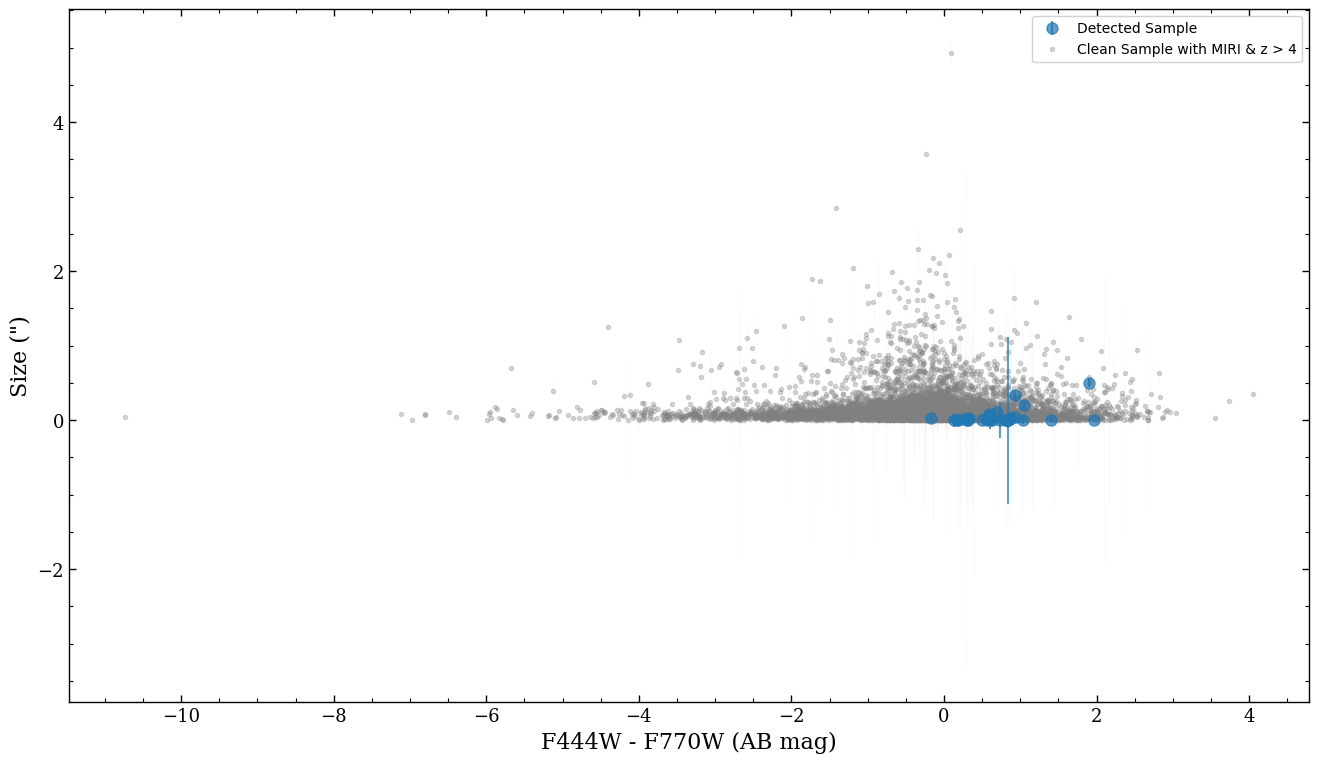

In [28]:
# size (use radius_sersic and radius_sersic_err) vs F444W-F770W (use cosmosWebHandler.get_cat_photom('condition_detection_reviewed')['flux_aper_f444w'] etc.) for the condition_detection_reviewed sample

# Apply local style context per-figure so global rcParams are not mutated
with mpl.rc_context(_rcparams):
    # fig, ax = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=constrained_layout, **kwargs)
    figSizeRedness, axSizeRedness = plt.subplots(1,1, figsize=(16, 9))

# phot = catalogHandler.get_photometry_catalog('condition_detection_reviewed')

mag444, mag444_err = catalogHandler.get_filter_magnitude('condition_detection_reviewed', 'F444W', aperture=aperature_for_analysis)
mag770, mag770_err = catalogHandler.get_filter_magnitude('condition_detection_reviewed', 'F770W', aperture=aperature_for_analysis)
x = mag444 - mag770
print(f"Number of points with finite x: {np.sum(np.isfinite(x))} out of {len(x)} total points in condition_detection_reviewed sample.")
y_arcsec, yerr_arcsec = catalogHandler.get_radius('condition_detection_reviewed')
y_arcsec = y_arcsec.astype(float)  # in arcseconds
yerr_arcsec = yerr_arcsec.astype(float) if yerr_arcsec is not None else None  # in arcseconds
ids = catalogHandler.get_ids('condition_detection_reviewed')

mask = np.isfinite(x) & np.isfinite(y_arcsec)
print(f"Number of points with finite x and y: {np.sum(np.isfinite(x) & np.isfinite(y_arcsec))} out of {len(x)} total points in condition_detection_reviewed sample.")

axSizeRedness.errorbar(x[mask], y_arcsec[mask], yerr=yerr_arcsec[mask], fmt='o', linestyle='none',
                       alpha=0.7, markersize=8, label="Detected Sample", zorder=1) if yerr_arcsec is not None else axSizeRedness.plot(x[mask], y_arcsec[mask], 'o', alpha=0.7, markersize=8, label="Detected Sample", zorder=1)


#plot the confirmed as red, tentative as yellow
#plot the radio as stars and the alma as diamonds
detected_marker_size = 25
confirmed_detection_color = 'red'
tentative_detection_color = 'orange'
alma_zorder = 3
radio_zorder = 4
for i, obj_id in enumerate(ids[mask]):
    if obj_id in confirmed_detection_radio_ids:
        axSizeRedness.scatter(x[mask][i], y_arcsec[mask][i],  marker='*', color=confirmed_detection_color, s=detected_marker_size, label="Confirmed Detection in Radio" if 'Confirmed Detection in Radio' not in axSizeRedness.get_legend_handles_labels()[1] else "", zorder=radio_zorder)
    elif obj_id in tentative_detection_radio_ids:
        axSizeRedness.scatter(x[mask][i], y_arcsec[mask][i], marker='*', color=tentative_detection_color, s=detected_marker_size, label="Tentative Detection in Radio" if 'Tentative Detection in Radio' not in axSizeRedness.get_legend_handles_labels()[1] else "", zorder=radio_zorder)
    if obj_id in confirmed_detection_alma_ids:
        axSizeRedness.scatter(x[mask][i], y_arcsec[mask][i], marker='D', color=confirmed_detection_color, s=detected_marker_size, label="Confirmed Detection in ALMA" if 'Confirmed Detection in ALMA' not in axSizeRedness.get_legend_handles_labels()[1] else "", zorder=alma_zorder)
    elif obj_id in tentative_detection_alma_ids:
        axSizeRedness.scatter(x[mask][i], y_arcsec[mask][i], marker='D', color=tentative_detection_color, s=detected_marker_size, label="Tentative Detection in ALMA" if 'Tentative Detection in ALMA' not in axSizeRedness.get_legend_handles_labels()[1] else "", zorder=alma_zorder)

    
    
    
    
#plot the rest of the points in the condition_clean_miri sample and zfinal > 4 as small gray points
print(f"Number of points in condition_clean_miri: {len(catalogHandler.get_photometry_catalog('condition_clean_miri'))}")
zgt4 = catalogHandler.get_z_redshift('condition_clean_miri') > 4
print(f"Number of points in condition_clean_miri with zfinal > 4: {np.sum(zgt4)}, fraction {np.sum(zgt4)/len(catalogHandler.get_photometry_catalog('condition_clean_miri')):.2%}")
mag444_clean, mag444_clean_err = catalogHandler.get_filter_magnitude('condition_clean_miri', 'F444W', aperture=aperature_for_analysis)
mag770_clean, mag770_clean_err = catalogHandler.get_filter_magnitude('condition_clean_miri', 'F770W', aperture=aperature_for_analysis)
x_clean = mag444_clean - mag770_clean
y_clean_arcsec, yerr_clean_arcsec = catalogHandler.get_radius('condition_clean_miri')
y_clean_arcsec = y_clean_arcsec.astype(float)  # in arcseconds
yerr_clean_arcsec = yerr_clean_arcsec.astype(float) if yerr_clean_arcsec is not None else None  # in arcseconds
ids_clean = catalogHandler.get_ids('condition_clean_miri')
mask_clean = np.isfinite(x_clean) & np.isfinite(y_clean_arcsec) & zgt4
print(f"Number of points in condition_clean_miri with finite x and y: {np.sum(np.isfinite(x_clean) & np.isfinite(y_clean_arcsec))} compared to {np.sum(mask_clean)} with the zfinal > 4 cut, total fraction of points with finite x and y that also have zfinal > 4: {np.sum(mask_clean)/len(catalogHandler.get_photometry_catalog('condition_clean_miri')):.2%}")
axSizeRedness.errorbar(x_clean[mask_clean], y_clean_arcsec[mask_clean], yerr=yerr_clean_arcsec[mask_clean], fmt='o', linestyle='none',
                       alpha=0.3, markersize=3, color='gray', label="Clean Sample with MIRI & z > 4", zorder=0, elinewidth=0.1) if yerr_clean_arcsec is not None else axSizeRedness.plot(x_clean[mask_clean], y_clean_arcsec[mask_clean], 'o', alpha=0.3, markersize=3, color='gray', label="Clean Sample with MIRI & z > 4", zorder=0)

#include a zoom-in inset on the plot that zooms in on the region where the detected objects are, say x between -1 and 4, and y between -0.00005 and 0.00015
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# axins = inset_axes(axSizeRedness, width="40%", height="40%", loc='upper left', borderpad=1)
# axins.errorbar(x[mask], y[mask], yerr=yerr[mask], fmt='o', linestyle='none',
#                alpha=0.7, markersize=5, label="Detected Sample", zorder=1)
# axins.errorbar(x_clean[mask_clean], y_clean[mask_clean], yerr=yerr_clean[mask_clean], fmt='o', linestyle='none',
#                alpha=0.3, markersize=3, color='gray', label="Clean Sample", zorder=0)
# #plot the masked out id = 334444, 369896, 413568 as red points with a star marker on the inset as well
# axins.errorbar(x[mask_sketchy], y[mask_sketchy], yerr=yerr[mask_sketchy], marker='*', color='red', markersize=5, linestyle='none', label="Detected Observed in Radio", zorder=2)
# #plot the labels for the masked out points on the inset as well
# for xi, yi, lab in zip(x[mask_sketchy], y[mask_sketchy], ids[mask_sketchy]):
#     axins.annotate(str(int(lab)) if np.issubdtype(np.asarray(lab).dtype, np.integer) else str(lab),
#                    (xi, yi), xytext=(4, 4), textcoords='offset points', fontsize=6)
# #put inset yticks on the right side
# axins.yaxis.tick_right()
# axins.set_xlim(-0.5, 2.5)
# axins.set_ylim(-0.00005, 0.00015)
    
    
    
axSizeRedness.set_xlabel('F444W - F770W (AB mag)')
axSizeRedness.set_ylabel('Size (")')
# axSizeRedness.set_xlim(-1, 4)
# axSizeRedness.set_ylim(-0.1, 1.2)
# axSizeRedness.set_yscale('log')
axSizeRedness.minorticks_on()
axSizeRedness.legend(loc='best', framealpha=0.9)

plt.show()


In [29]:
#print id and properties of the points with F444W - F770W < 0 (blue points in the plot)
blue_mask = x < 0
print("Points with F444W - F770W < 0:")
for idx in np.where(blue_mask)[0]:
    print(f"ID {ids[idx]}: F444W - F770W = {x[idx]}, radius_sersic = {y_arcsec[idx]}, radius_sersic_err = {yerr_arcsec[idx]}")

Points with F444W - F770W < 0:
ID 634457: F444W - F770W = -0.16564175257578384, radius_sersic = 0.03489329739336422, radius_sersic_err = 0.0160048864687027


#### sersic index vs redness

Number of points in condition_clean_miri with finite x and y: 177816 compared to 12293 with the zfinal > 4 cut


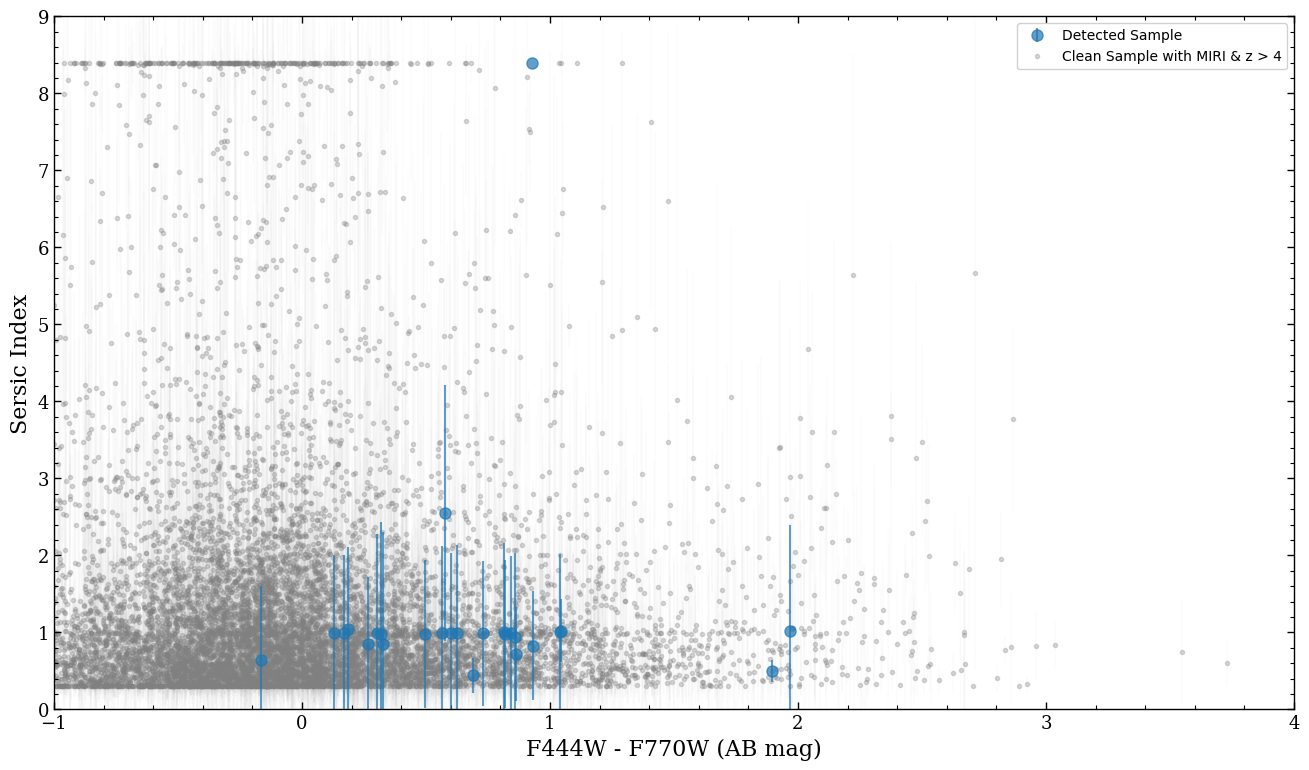

In [30]:
# sersic and sersic_err vs F444W-F770W (use cosmosWebHandler.get_cat_photom('condition_detection_reviewed')['flux_aper_f444w'] etc.) for the condition_detection_reviewed sample
#not an option in the JADES catalogs, but for the COSMOS-Web catalog, the sersic and sersic_err are in the 'condition_detection_aper' filter

if isinstance(catalogHandler, JadesHandler):
    raise NotImplementedError("Sersic radius and error not available in JADES catalogs, so cannot make the Sersic vs Redness plot for JADES at this time.")

# Apply local style context per-figure so global rcParams are not mutated
with mpl.rc_context(_rcparams):
    # fig, ax = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=constrained_layout, **kwargs)
    figSersicRedness, axSersicRedness = plt.subplots(1,1, figsize=(16, 9))

phot = catalogHandler.get_cat_photom('condition_detection_reviewed')

mag444, mag444_err = catalogHandler.get_filter_magnitude('condition_detection_reviewed', 'F444W', aperture=aperature_for_analysis)
mag770, mag770_err = catalogHandler.get_filter_magnitude('condition_detection_reviewed', 'F770W', aperture=aperature_for_analysis)
x = mag444 - mag770
y = _getcol(phot, 'sersic').astype(float)
yerr = _getcol(phot, 'sersic_err').astype(float)
ids = _getcol(phot, 'ID', 'id')

mask = np.isfinite(x) & np.isfinite(y)

#mask out id = 334444, 369896, 413568
mask &= ~np.isin(ids, [334444, 369896, 413568])

axSersicRedness.errorbar(x[mask], y[mask], yerr=yerr[mask], fmt='o', linestyle='none',
                       alpha=0.7, markersize=8, label="Detected Sample", zorder=1)

#plot the masked out id = 334444, 369896, 413568 as red points with a star marker
# mask_sketchy = np.isin(ids, [334444, 369896, 413568])
# axSersicRedness.errorbar(x[mask_sketchy], y[mask_sketchy], yerr=yerr[mask_sketchy], marker='*', color='red', linestyle='none', markersize=8, label="Detected Observed in Radio", zorder=2)


#plot the confirmed as red, tentative as yellow
#plot the radio as stars and the alma as diamonds
for i, obj_id in enumerate(ids[mask]):
    if obj_id in confirmed_detection_radio_ids:
        axSersicRedness.scatter(x[mask][i], y[mask][i],  marker='*', color=confirmed_detection_color, s=detected_marker_size, label="Confirmed Detection in Radio" if 'Confirmed Detection in Radio' not in axSersicRedness.get_legend_handles_labels()[1] else "", zorder=radio_zorder)
    elif obj_id in tentative_detection_radio_ids:
        axSersicRedness.scatter(x[mask][i], y[mask][i], marker='*', color=tentative_detection_color, s=detected_marker_size, label="Tentative Detection in Radio" if 'Tentative Detection in Radio' not in axSersicRedness.get_legend_handles_labels()[1] else "", zorder=radio_zorder)
    if obj_id in confirmed_detection_alma_ids:
        axSersicRedness.scatter(x[mask][i], y[mask][i], marker='D', color=confirmed_detection_color, s=detected_marker_size, label="Confirmed Detection in ALMA" if 'Confirmed Detection in ALMA' not in axSersicRedness.get_legend_handles_labels()[1] else "", zorder=alma_zorder)
    elif obj_id in tentative_detection_alma_ids:
        axSersicRedness.scatter(x[mask][i], y[mask][i], marker='D', color=tentative_detection_color, s=detected_marker_size, label="Tentative Detection in ALMA" if 'Tentative Detection in ALMA' not in axSersicRedness.get_legend_handles_labels()[1] else "", zorder=alma_zorder)

    
#plot the rest of the points in the condition_clean_miri sample and zfinal > 4 as small gray points
phot_clean_miri = catalogHandler.get_cat_photom('condition_clean_miri')
zgt4 = catalogHandler.get_cat_lephare('condition_clean_miri')['zfinal'] > 4
mag444_clean = _getcol(phot_clean_miri, 'mag_aper_f444w')[:, 2]
mag770_clean = _getcol(phot_clean_miri, 'mag_aper_f770w')[:, 2]
x_clean = mag444_clean - mag770_clean
y_clean = _getcol(phot_clean_miri, 'sersic').astype(float)
yerr_clean = _getcol(phot_clean_miri, 'sersic_err').astype(float)
ids_clean = _getcol(phot_clean_miri, 'ID', 'id')
mask_clean = np.isfinite(x_clean) & np.isfinite(y_clean) & zgt4
print(f"Number of points in condition_clean_miri with finite x and y: {np.sum(np.isfinite(x_clean) & np.isfinite(y_clean))} compared to {np.sum(mask_clean)} with the zfinal > 4 cut")
axSersicRedness.errorbar(x_clean[mask_clean], y_clean[mask_clean], yerr=yerr_clean[mask_clean], fmt='o', linestyle='none',
                       alpha=0.3, markersize=3, color='gray', label="Clean Sample with MIRI & z > 4", zorder=0, elinewidth=0.1)

    
axSersicRedness.set_xlabel('F444W - F770W (AB mag)')
axSersicRedness.set_ylabel('Sersic Index')
axSersicRedness.set_xlim(-1, 4)
axSersicRedness.set_ylim(-0.00002, 9)
# axSersicRedness.set_yscale('log')
axSersicRedness.minorticks_on()
#tick marks on every integer value of y from 0 to 8
axSersicRedness.set_yticks(np.arange(0, 10, 1))
axSersicRedness.legend(loc='best', framealpha=0.9)

plt.show()

#### color vs redness

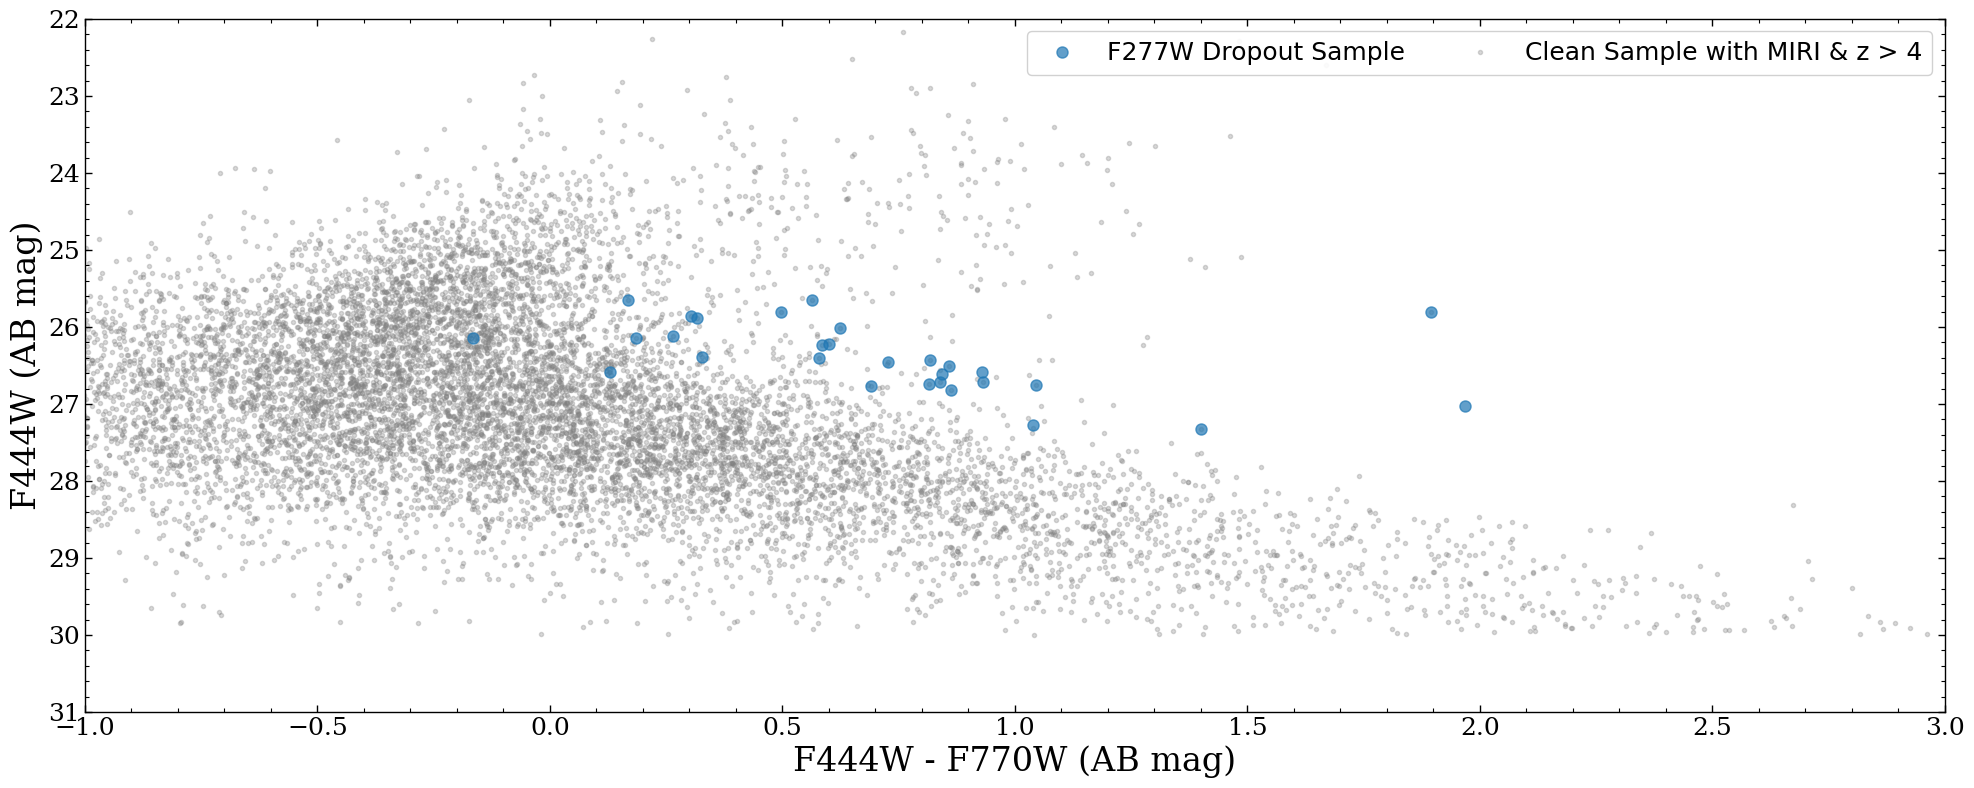

In [49]:
# plot F444W-F770W vs F444W for the condition_detection_reviewed sample, with the same color coding as before (detected sample in blue, masked out points in red with star marker, clean sample with MIRI and z > 4 in gray)
with mpl.rc_context(_rcparams):
    figRednessMag, axRednessMag = plt.subplots(1,1, figsize=(24, 9))
# phot = catalogHandler.get_cat_photom('condition_detection_reviewed')
mag444, mag444_err = catalogHandler.get_filter_magnitude('condition_detection_reviewed', 'F444W', aperture=aperature_for_analysis)
mag770, mag770_err = catalogHandler.get_filter_magnitude('condition_detection_reviewed', 'F770W', aperture=aperature_for_analysis)
x = mag444 - mag770
y = mag444
ids = np.asarray(catalogHandler.get_ids('condition_detection_reviewed'))
if ids.dtype.names is not None:
    ids = np.array([tuple(v)[0] for v in ids], dtype=np.int64)
else:
    ids = ids.astype(np.int64, copy=False)

mask = np.isfinite(x) & np.isfinite(y)
special_ids = [] #[334444, 369896, 413568]

if len(special_ids) == 0:
    mask_sketchy = np.zeros_like(mask, dtype=bool)
else:
    special_ids_arr = np.asarray(special_ids, dtype=np.int64)
    mask_sketchy = np.isin(ids, special_ids_arr)

axRednessMag.errorbar(x[mask], y[mask], fmt='o', linestyle='none',
                       alpha=0.7, markersize=8, label="F277W Dropout Sample", zorder=1)
# axRednessMag.errorbar(x[mask_sketchy], y[mask_sketchy], marker='*', color='red', linestyle='none', markersize=8, label="Detected Observed in Radio", zorder=2)



#plot the confirmed as red, tentative as yellow
#plot the radio as stars and the alma as diamonds
for i, obj_id in enumerate(ids[mask]):
    if obj_id in confirmed_detection_radio_ids:
        axRednessMag.scatter(x[mask][i], y[mask][i],  marker='*', color=confirmed_detection_color, s=detected_marker_size, label="Confirmed Detection in Radio" if 'Confirmed Detection in Radio' not in axRednessMag.get_legend_handles_labels()[1] else "", zorder=radio_zorder)
    elif obj_id in tentative_detection_radio_ids:
        axRednessMag.scatter(x[mask][i], y[mask][i], marker='*', color=tentative_detection_color, s=detected_marker_size, label="Tentative Detection in Radio" if 'Tentative Detection in Radio' not in axRednessMag.get_legend_handles_labels()[1] else "", zorder=radio_zorder)
    if obj_id in confirmed_detection_alma_ids:
        axRednessMag.scatter(x[mask][i], y[mask][i], marker='D', color=confirmed_detection_color, s=detected_marker_size, label="Confirmed Detection in ALMA" if 'Confirmed Detection in ALMA' not in axRednessMag.get_legend_handles_labels()[1] else "", zorder=alma_zorder)
    elif obj_id in tentative_detection_alma_ids:
        axRednessMag.scatter(x[mask][i], y[mask][i], marker='D', color=tentative_detection_color, s=detected_marker_size, label="Tentative Detection in ALMA" if 'Tentative Detection in ALMA' not in axRednessMag.get_legend_handles_labels()[1] else "", zorder=alma_zorder)



# phot_clean_miri = catalogHandler.get_cat_photom('condition_clean_miri')
zvals = np.asarray(catalogHandler.get_z_redshift('condition_clean_miri'))
if zvals.dtype.names is not None:
    zvals = np.array([tuple(v)[0] for v in zvals], dtype=float)
else:
    zvals = zvals.astype(float, copy=False)
zgt4 = np.isfinite(zvals) & (zvals > 4)
mag444_clean, mag444_clean_err = catalogHandler.get_filter_magnitude('condition_clean_miri', 'F444W', aperture=aperature_for_analysis)
mag770_clean, mag770_clean_err = catalogHandler.get_filter_magnitude('condition_clean_miri', 'F770W', aperture=aperature_for_analysis)

x_clean = mag444_clean - mag770_clean
y_clean = mag444_clean
# yerr_clean = mag444_err_clean # for simplicity, just use the F444W error as the y error
ids_clean = np.asarray(catalogHandler.get_ids('condition_clean_miri'))
mask_clean = np.isfinite(x_clean) & np.isfinite(y_clean) & zgt4 #& np.isfinite(yerr_clean)
axRednessMag.errorbar(x_clean[mask_clean], y_clean[mask_clean], fmt='o', linestyle='none',
                       alpha=0.3, markersize=3, color='gray', label="Clean Sample with MIRI & z > 4", zorder=0, elinewidth=0.1)
axRednessMag.set_xlabel('F444W - F770W (AB mag)', fontsize=24)
axRednessMag.set_ylabel('F444W (AB mag)', fontsize=24)
axRednessMag.set_xlim(-1, 3)
axRednessMag.set_ylim(22, 31)
axRednessMag.invert_yaxis()
axRednessMag.minorticks_on()
#increase fontsize of tick labels
axRednessMag.tick_params(axis='both', which='major', labelsize=18)
# axRednessMag.legend(loc='best', framealpha=0.9, fontsize=12, ncol=2)
axRednessMag.legend(loc='upper right', framealpha=0.9, fontsize=18, ncol=2)

plt.show()

#### effective resolution

##### overplot on pdf plot

In [ ]:
%matplotlib qt  

In [ ]:
PDF_PLOT_PATH = '/Volumes/Apple SDXC Reader Media/dusty-red/data/Screenshot 2026-06-12 at 15.05.11.png'


import matplotlib.pyplot as plt, matplotlib.image as mpimg, numpy as np

img = mpimg.imread(PDF_PLOT_PATH)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)
ax.set_title("Click 2 X-axis ticks, then 2 Y-axis ticks (4 clicks total)")

# Blocks until you click 4 points. timeout=0 -> wait forever.
# Right-click undoes the last point; middle-click/Enter finishes early.
pts = plt.ginput(4, timeout=0)
print(pts)   # [(x1,y1), (x2,y2), (x3,y3), (x4,y4)] in pixel coords


In [ ]:
(xp1, _), (xp2, _), (_, yp1), (_, yp2) = pts   # ignore the off-axis coordinate

x_data = np.array([22, 27]); x_pix = np.array([xp1, xp2])   # data values you clicked
y_data = np.array([0.0,  0.1]); y_pix = np.array([yp1, yp2])

mx, bx = np.polyfit(x_data, x_pix, 1)
my, by = np.polyfit(y_data, y_pix, 1)

def to_pixels(x, y):
    return mx*np.asarray(x) + bx, my*np.asarray(y) + by


In [ ]:
#turn off matplotlib qt backend and go back to inline
%matplotlib inline

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))


#from the condition_detection_reviewed sample, y values are the radius_sersic in arcseconds, and x values are the F444W magnitude
x = catalogHandler.get_cat_photom('condition_detection_reviewed')['mag_aper_f444w'][:, 2] # F444W magnitude
y = catalogHandler.get_cat_photom('condition_detection_reviewed')['radius_sersic'].astype(float) * 3600 # radius_sersic in arcseconds
x_clean = x[np.isfinite(x) & np.isfinite(y)]
y_clean = y[np.isfinite(x) & np.isfinite(y)]




ax.imshow(img)
px, py = to_pixels(x_clean, y_clean)          # your real data
ax.scatter(px, py, c='blue', s=25, zorder=5, alpha=0.7)
ax.set_ylim(None, 0.15)
ax.axis('off')
plt.show()

#plot points in own graph
fig, ax = plt.subplots(figsize=(4, 3))
ax.scatter(x_clean, y_clean, c='blue', s=8, zorder=5)
ax.set_xlabel('F444W (AB mag)')
ax.set_ylabel('Radius Sersic (arcsec)')
ax.set_title('Radius Sersic vs F444W for condition_detection_reviewed sample')
ax.invert_xaxis()  # because magnitude axis is usually inverted
# ax.set_yscale('log')  # if radius_sersic spans several orders of magnitude
ax.minorticks_on()
plt.show()


##### use the extracted data

In [56]:
# use extracted data of the original plot
EXTRACTED_EFF_RESOLUTION_JSON_PATH = '/Volumes/Apple SDXC Reader Media/dusty-red/data/misc/effective_resolution_extracted_data.json'
import json
with open(EXTRACTED_EFF_RESOLUTION_JSON_PATH, 'r') as f:
    extracted = json.load(f)
# print the extracted data
print(extracted)


{'calibration': {'plot_bounds_px': {'left': 227, 'right': 1000, 'top': 72, 'bottom': 783}, 'x_axis': {'label': 'm444 [AB mag]', 'min': 21.5, 'max': 27.5}, 'y_axis': {'label': 'Reff,444 [arcsec]', 'min': 0.0, 'max': 0.1}, 'y_axis_right': {'label': 'Reff,444 [pc @ z=6]', 'min': 0, 'max': 571, 'scale': '5714 pc/arcsec'}}, 'psf_hwhm_line': {'type': 'horizontal', 'y_arcsec': 0.07, 'y_pc_z6': 400.0, 'label': 'PSF HWHM'}, 'effective_resolution_limit': {'type': 'exponential', 'formula': 'Reff = exp(0.3562 * m444 - 12.5911) arcsec', 'points': [{'m444': 21.5, 'Reff_arcsec': 0.007206, 'Reff_pc_z6': 41.2}, {'m444': 21.6, 'Reff_arcsec': 0.007468, 'Reff_pc_z6': 42.7}, {'m444': 21.7, 'Reff_arcsec': 0.007738, 'Reff_pc_z6': 44.2}, {'m444': 21.8, 'Reff_arcsec': 0.008019, 'Reff_pc_z6': 45.8}, {'m444': 21.9, 'Reff_arcsec': 0.00831, 'Reff_pc_z6': 47.5}, {'m444': 22.0, 'Reff_arcsec': 0.008611, 'Reff_pc_z6': 49.2}, {'m444': 22.1, 'Reff_arcsec': 0.008923, 'Reff_pc_z6': 51.0}, {'m444': 22.2, 'Reff_arcsec': 0.0

Effective resolution dashed line formula: exp(0.3562 * x + 12.5911) arcsec
Getting flux for filter 'condition_detection_reviewed', band 'f444w', aperture 0: column names = 'F444W_CIRC0', 'F444W_CIRC0_ei'
Calculating magnitude for filter 'condition_detection_reviewed', band 'f444w', aperture 0: flux = [11.279788 11.46318   7.106307  4.855247 29.868835], flux_err = [0.5491709  0.63536024 0.87990266 0.8621542  0.4360861 ]
check x,y : [28.769247 28.751738 29.27089  29.684471 27.711954 27.89228  30.135227
 29.413239 29.967203 29.68793  29.882004 29.98251  29.980242 30.450953
 29.099857 29.190807 28.934687 29.545774 29.514433 30.429228 30.669134
 29.600035 29.679243 29.711252 30.573797 32.07788  29.9323   29.645323
 29.198315 30.433605 28.982347 29.53317  29.720686 29.987907 30.365637
 29.482147 29.618555 28.874619 30.746527 30.243816 30.25657  29.283289
 29.246206 30.499565 29.73157  29.366936 29.1936   29.239464 29.766228
 31.941471 28.96399  29.814007 28.88568  29.292639 28.748413 28.4729

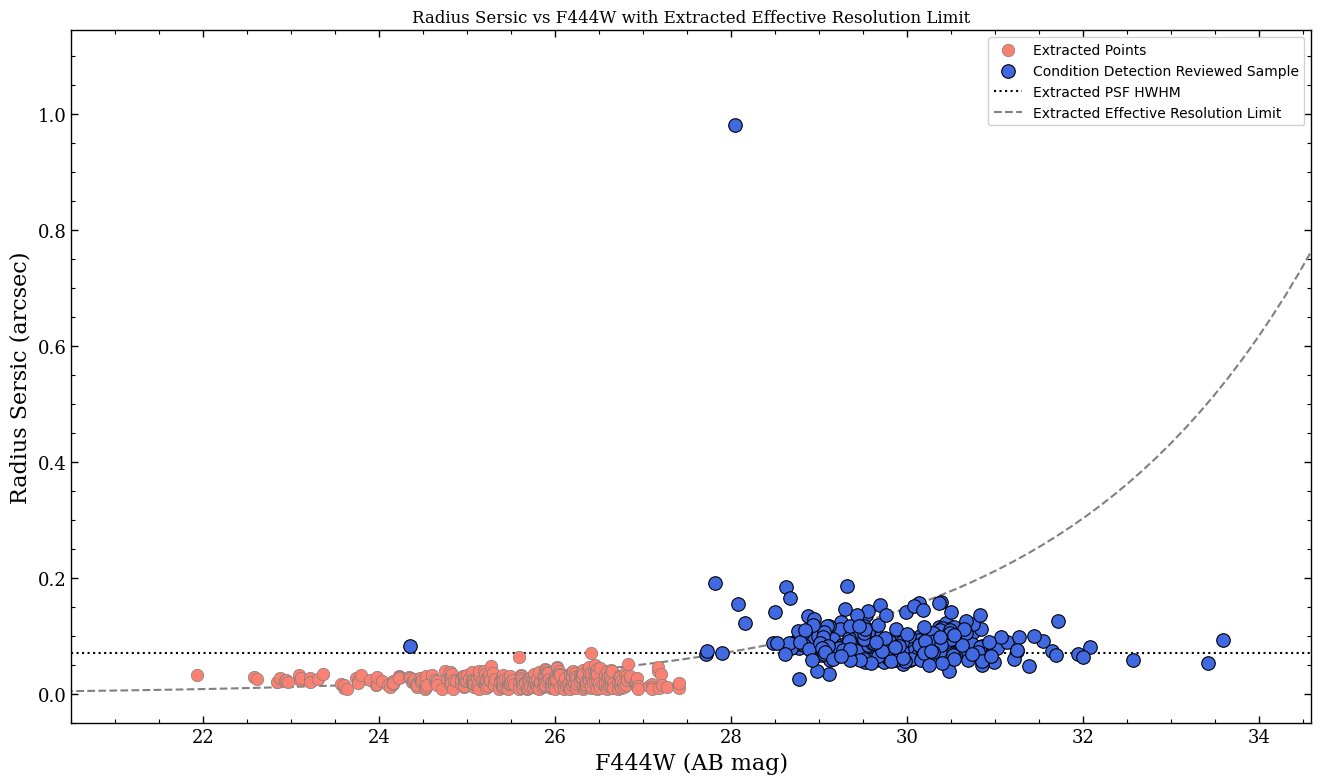

In [69]:
plot_bounds_ext = extracted['calibration']['plot_bounds_px']
x_axis_ext_data = extracted['calibration']['x_axis']
y_axis_ext_data = extracted['calibration']['y_axis']
y_axis_right_ext_data = extracted['calibration']['y_axis_right']

psf_ext_data = extracted['psf_hwhm_line']
psf_formula_type = psf_ext_data['type'] #should be horizontal line
psf_formula_formula_y = psf_ext_data['y_arcsec'] #should be a single y value in arcseconds, since it's a horizontal line

eff_resolution_limit_ext_data = extracted['effective_resolution_limit']
eff_resolution_dashed_line_formula_type = eff_resolution_limit_ext_data['type'] # should be exponential
eff_resolution_dashed_line_formula_formula = eff_resolution_limit_ext_data['formula'] # should be exp(a * x + b) arcsec
#parse to get the a and b values from the formula
eff_resolution_dashed_line_formula_a = eff_resolution_dashed_line_formula_formula.split('exp(')[1].split(' * m444 - ')[0]
eff_resolution_dashed_line_formula_b = eff_resolution_dashed_line_formula_formula.split('exp(')[1].split(' * m444 - ')[1].split(')')[0]
eff_resolution_dashed_line_formula_a = float(eff_resolution_dashed_line_formula_a)
eff_resolution_dashed_line_formula_b = float(eff_resolution_dashed_line_formula_b)
print(f"Effective resolution dashed line formula: exp({eff_resolution_dashed_line_formula_a} * x + {eff_resolution_dashed_line_formula_b}) arcsec")

ext_points = eff_resolution_limit_ext_data['points']
ext_points_x = [p['m444'] for p in ext_points]
ext_points_y = [p['Reff_arcsec'] for p in ext_points]

data_points_ext = extracted['data_points']
data_points_ext_x = [p['m444'] for p in data_points_ext]
data_points_ext_y = [p['Reff_arcsec'] for p in data_points_ext]

# print(np.column_stack((ext_points_x, ext_points_y)))
# print(np.column_stack((data_points_ext_x, data_points_ext_y)))



with mpl.rc_context(_rcparams):
    figExt, axExt = plt.subplots(1,1, figsize=(16, 9))
    
#get the x and y data for the condition_detection_reviewed sample, using the same columns as before (F444W magnitude and radius_sersic in arcseconds)
# x = catalogHandler.get_photometry_catalog('condition_detection_reviewed')['mag_aper_f444w'][:, 2] # F444W magnitude
# y = catalogHandler.get_photometry_catalog('condition_detection_reviewed')['radius_sersic'].astype(float) * 3600 # radius_sersic in arcseconds
x = catalogHandler.get_filter_magnitude('condition_detection_reviewed', 'F444W', aperture=aperature_for_analysis)[0]
y = catalogHandler.get_radius('condition_detection_reviewed')[0]
print(f"check x,y : {x}, {y}")
x_clean = x[np.isfinite(x) & np.isfinite(y)]
y_clean = y[np.isfinite(x) & np.isfinite(y)]


axExt.scatter(data_points_ext_x, data_points_ext_y, c='salmon', s=80, zorder=5, label='Extracted Points', edgecolor='grey', linewidth=0.5)
axExt.scatter(x_clean, y_clean, c='royalblue', s=95, zorder=5, label='Condition Detection Reviewed Sample', edgecolor='black', linewidth=0.8)

#create dashed line for the PSF HWHM using the y value from the extracted data, which should be a horizontal line
axExt.axhline(psf_formula_formula_y, linestyle='dotted', color='black', label='Extracted PSF HWHM')

#create equation for the effective resolution limit dashed line using the formula from the extracted data, and plot it on top of the original plot using the same x values as the extracted points and the y values from the formula
import numpy as np
# note type formula is exp(a * x + b), where a and b are the values we parsed out above, and x is the F444W magnitude
# x_for_formula = np.array(ext_points_x)
#make x for formula go the entire range of the x axis of the plot
x_min = min(min(ext_points_x), min(x_clean))
x_max = max(max(ext_points_x), max(x_clean))
x_for_formula = np.linspace(x_min - 2, x_max + 2, 100)
y_for_formula = np.exp(eff_resolution_dashed_line_formula_a * x_for_formula - eff_resolution_dashed_line_formula_b)
axExt.plot(x_for_formula, y_for_formula, linestyle='dashed', color='grey', label='Extracted Effective Resolution Limit')
# instead use ext_points_x and ext_points_y to plot the effective resolution limit as a dashed line, since the formula is just a fit to those points and may not be accurate outside of that range
# axExt.plot(ext_points_x, ext_points_y, linestyle='dashed', color='grey', label='Extracted Effective Resolution Limit')

#plot the confirmed and tentative detections on top of everything else, using the same color coding as before (confirmed in red, tentative in orange, radio as stars, ALMA as diamonds)
for i, obj_id in enumerate(ids):
    if obj_id in confirmed_detection_radio_ids:
        axExt.scatter(x[i], y[i],  marker='*', color=confirmed_detection_color, s=detected_marker_size*4, label="Confirmed Detection in Radio" if 'Confirmed Detection in Radio' not in axExt.get_legend_handles_labels()[1] else "", zorder=radio_zorder+15)
    elif obj_id in tentative_detection_radio_ids:
        axExt.scatter(x[i], y[i], marker='*', color=tentative_detection_color, s=detected_marker_size*4, label="Tentative Detection in Radio" if 'Tentative Detection in Radio' not in axExt.get_legend_handles_labels()[1] else "", zorder=radio_zorder+15)
    if obj_id in confirmed_detection_alma_ids:
        axExt.scatter(x[i], y[i], marker='D', color=confirmed_detection_color, s=detected_marker_size*1.5, label="Confirmed Detection in ALMA" if 'Confirmed Detection in ALMA' not in axExt.get_legend_handles_labels()[1] else "", zorder=alma_zorder+10)
    elif obj_id in tentative_detection_alma_ids:
        axExt.scatter(x[i], y[i], marker='D', color=tentative_detection_color, s=detected_marker_size*1.5, label="Tentative Detection in ALMA" if 'Tentative Detection in ALMA' not in axExt.get_legend_handles_labels()[1] else "", zorder=alma_zorder+10)

axExt.set_xlabel('F444W (AB mag)')
axExt.set_ylabel('Radius Sersic (arcsec)')
axExt.set_title('Radius Sersic vs F444W with Extracted Effective Resolution Limit')
# axExt.invert_xaxis()
# axExt.set_yscale('log')
axExt.legend(loc='best', framealpha=0.9)



# axExt.set_ylim(-0.0075, 0.1)

# axExt.set_xlim(x_axis_ext_data['min'], x_axis_ext_data['max'])

axExt.set_xlim(x_min - 1, x_max + 1)



plt.show()



# cross-ref

## cross-ref super-deblended

In [ ]:
superDeblendedHandler = SuperDeblendedHandler(SUPER_DEBLENDED_CATALOG)
superDeblendedHandler.load_catalog()

#### cross-ref via id

In [ ]:
# print(superDeblendedHandler.cat_photom['original'].colnames)
#get the objects in the super-deblended catalog that are in the 'condition_detection_reviewed' catalog, and print out their fluxes in the super-deblended catalog.
for obj in catalogHandler.get_cat_photom('condition_detection_reviewed'):
    # print(obj)
    obj_id = obj['id']
    print(f"Object ID: {obj_id} in condition_detection_reviewed")
    # print(superDeblendedHandler.cat_photom['original'])
    obj_idx_superDeblended = np.nan
    for i, row in enumerate(superDeblendedHandler.cat_photom['original']['ID']):
        if row == obj_id:
            obj_idx_superDeblended = i
            break
    if np.isnan(obj_idx_superDeblended):
        print(f"Object ID: {obj_id} not found in super-deblended catalog")
        continue
    print(f"\nOriginal: \n{catalogHandler.get_cat_photom('original')[obj_id]}")
    print(f"Super Deblended: \n{superDeblendedHandler.cat_photom['original'][obj_idx_superDeblended]}")
    print(f"Object ID: {superDeblendedHandler.cat_photom['original'][obj_idx_superDeblended]['ID']} in super-deblended catalog")
    superDeblended_obj = superDeblendedHandler.cat_photom['original'][obj_idx_superDeblended]
    print(f"Object ID: {obj_id}, Super-Deblended photo_red : {superDeblended_obj['z_phot']}, spect_red: {superDeblended_obj['z_spec']} \n")

#### cross-ref via RA,DEC

In [ ]:
#instead match the objects by ra, dec with tolerance of 0.5 arcsec, and print out their fluxes in the super-deblended catalog.
# Vectorized cross-match: build the SkyCoord arrays once and let match_to_catalog_sky do the
# nearest-neighbour search in compiled C (KD-tree) over all objects at once, instead of the
# O(N*M) Python double loop that constructed a SkyCoord per pair.
from astropy.coordinates import SkyCoord
import astropy.units as u
tolerance = 1 * u.arcsec

obj_cat = catalogHandler.get_cat_photom('condition_detection_reviewed')
sd_cat  = superDeblendedHandler.cat_photom['original']

obj_coords = SkyCoord(obj_cat['ra'] * u.deg, obj_cat['dec'] * u.deg)
sd_coords  = SkyCoord(sd_cat['RA'] * u.deg, sd_cat['Dec'] * u.deg)

# For every object, find the single closest super-deblended source (vectorized).
sd_idx, sep2d, _ = obj_coords.match_to_catalog_sky(sd_coords)
within_tol = sep2d < tolerance

superDeblended_ids_matched = []
matched_super_deblended : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the super-deblended catalog that matches it.
closest_match_super_deblended : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the super-deblended catalog that is the closest match to it, even if it is outside the tolerance.

original_cols_to_print = ['id', 'ra', 'dec', 'flux_aper_f115w', 'flux_err_aper_f115w', 'flux_aper_f150w', 'flux_err_aper_f150w', 'flux_aper_f444w', 'flux_err_aper_f444w', 'flux_aper_f770w', 'flux_err_aper_f770w']

for obj, j, sep, ok in zip(obj_cat, sd_idx, sep2d, within_tol):
    row = sd_cat[j]
    if ok:
        print(f"\nObject ID: {obj['id']} in condition_detection_reviewed matches with Super-Deblended ID: {row['ID']} at separation {sep.arcsec:.2f} arcsec")
        original_info = {col: obj[col] for col in original_cols_to_print}
        print(f"Original: \n{original_info}")
        print(f"Super Deblended: \n{row}")
        print(f"Object ID: {row['ID']} in super-deblended catalog")
        print(f"Object ID: {obj['id']}, Super-Deblended photo_red : {row['z_phot']}, spect_red: {row['z_spec']} \n\n")
        superDeblended_ids_matched.append(row['ID'])
        matched_super_deblended[obj['id']] = row
    else:
        print(f"Object ID: {obj['id']} not found in super-deblended catalog within {tolerance}")
        closest_match_super_deblended[obj['id']] = row
        print(f"Closest match is Super-Deblended ID: {row['ID']} at separation {sep.arcsec:.2f} arcsec\n\n")

# #filter the super-deblended catalog to only include the matched objects, and print out the number of matched objects and their IDs.
matched_super_deblended = superDeblendedHandler.get_filter_cut(filtername='matched_super_deblended', filter_func=lambda photom: np.isin(photom['ID'], superDeblended_ids_matched), filter_to_take_from='original')


In [ ]:
print(f"Number of matched objects in super-deblended catalog: {len(superDeblended_ids_matched)}, matched catalog length: {len(superDeblendedHandler.get_cat_photom('matched_super_deblended'))}")
print(superDeblendedHandler.get_cat_photom('matched_super_deblended'))

## cross-ref MIGHTEE

In [ ]:
mighteeHandler = MighteeHandler(MIGHTEE_CATALOG)
mighteeHandler.load_catalog()
print(mighteeHandler.hdr)

### get image maps

In [ ]:
#given that MIGHTEE catalog is just the intensity image, where each col and row corresponds to a pixel in the image, we can use the WCS information in the header to convert the ra, dec of our objects to pixel coordinates, and then extract the intensity value at those pixel coordinates from the MIGHTEE catalog.

# The MIGHTEE header keeps leftover FREQ/STOKES axes (4-D WCS) over a 2-D image,
# so use .celestial to get a clean 2-D (RA, Dec) WCS that takes a single SkyCoord.
mightee_header = mighteeHandler.hdr
mightee_wcs = WCS(mightee_header).celestial
print(f"distance between pixels in arcsec: {mightee_wcs.proj_plane_pixel_scales()[0].to(u.arcsec)}")

# Ensure we index a 2-D ndarray (Astropy Table does not support [y, x] tuple access)
mightee_image = mighteeHandler.cat_photom['original']
if hasattr(mightee_image, "as_array"):  # astropy.table.Table
    mightee_image = np.asarray(mightee_image.as_array().tolist(), dtype=float)
else:
    mightee_image = np.asarray(mightee_image, dtype=float)
mightee_image = np.squeeze(mightee_image)


In [ ]:
#include L band, S band, and VLA 3GHZ images
lBand_fits = fits.open(L_BAND_IMAGE)
sBand_fits = fits.open(S_BAND_IMAGE)
vla_fits = fits.open(VLA_3GHZ_IMAGE)

lBand_data = lBand_fits[0].data
lBand_hdr = lBand_fits[0].header

sBand_data = sBand_fits[0].data
sBand_hdr = sBand_fits[0].header

vla_data = vla_fits[0].data
vla_hdr = vla_fits[0].header

# print(f"L Band image shape: {lBand_data.shape}, header keys: {lBand_hdr}")
# print(f"S Band image shape: {sBand_data.shape}, header keys: {sBand_hdr}")
# print(f"VLA 3GHz image shape: {vla_data.shape}, header keys: {vla_hdr}")
# print(f"L Band WCS info: {WCS(lBand_hdr)} \n")
# print(f"S Band WCS info: {WCS(sBand_hdr)} \n")
# print(f"VLA 3GHz WCS info: {WCS(vla_hdr)} \n")

lBand_image = np.squeeze(lBand_data)
sBand_image = np.squeeze(sBand_data)
vla_image = np.squeeze(vla_data)

lBand_wcs = WCS(lBand_hdr)
sBand_wcs = WCS(sBand_hdr)
vla_wcs = WCS(vla_hdr)

### aside, plot mini plots for mightee points around sources

In [ ]:
zoom_size_arcsec = 5.75 + 10 # in arcsec
zoom_size_pixels = int(zoom_size_arcsec / mightee_wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value)  # convert zoom size to pixels
print(f"Zoom size in pixels: {zoom_size_pixels} pixels (for {zoom_size_arcsec} arcsec at MIGHTEE pixel scale)")

In [ ]:
import matplotlib.patheffects as pe
def include_scale_bar(fig, ax, wcs, x_min, x_max, y_min, y_max, scale_bar_length_arcsec=2, color='white', fontsize=8):
    scale_bar_length_pixels = scale_bar_length_arcsec / wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
    crop_h, crop_w = (y_max - y_min), (x_max - x_min)
    margin = 0.05 * crop_h
    x0 = margin
    y0 = margin  # anchor near the bottom-left of the actual crop
    outline = [pe.withStroke(linewidth=4, foreground='black')]
    ax.plot([x0, x0 + scale_bar_length_pixels], [y0, y0], color=color, linewidth=2.5,
            solid_capstyle='butt', path_effects=outline)
    ax.text(x0, y0 + 0.02 * crop_h, f'{scale_bar_length_arcsec} arcsec', color=color,
            fontsize=fontsize, va='bottom', path_effects=outline)
    ax.axis('off')

def include_interface_box(fig, ax, x_pixel, y_pixel, wcs, x_min, y_min, box_size_arcsec=5.75, color='dodgerblue'):
    box_size_pixels = box_size_arcsec / wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
    rect = plt.Rectangle((x_pixel - x_min - box_size_pixels / 2, y_pixel - y_min - box_size_pixels / 2),
                            box_size_pixels, box_size_pixels, edgecolor=color, facecolor='none',
                            linestyle='--', label='Inspection equivalent')
    ax.add_patch(rect)

def include_marker_scaled(fig, ax, x_pixel, y_pixel, wcs, x_min, y_min, marker_size_arcsec=5.2, color='red'):
    pixscale_arcsec = wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
    radius_pix = marker_size_arcsec / pixscale_arcsec  # radius in image pixels

    p0 = ax.transData.transform((0, 0))
    p1 = ax.transData.transform((radius_pix, 0))
    radius_pts = (p1[0] - p0[0]) * 72.0 / fig.dpi

    sizeOfMarker = np.pi * (radius_pts ** 2)  # scatter expects area in points^2
    ax.scatter(x_pixel - x_min, y_pixel - y_min, s=sizeOfMarker, edgecolor=color, facecolor='none',
                label=f'ID: {obj_id} Res @ {marker_size_arcsec}"')

def include_ellipse_scaled(fig, ax, x_pixel, y_pixel, obj_id, wcs, x_min, y_min, a_arcsec=5.2, b_arcsec=3.0, pa_deg=30, color='red'):
    # print(f"Including ellipse with a={a_arcsec}\" and b={b_arcsec}\" at PA={pa_deg} degrees for object ID: {obj_id}")
    pixscale_arcsec = wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value
    a_pix = a_arcsec / pixscale_arcsec  # semi-major axis in image pixels
    b_pix = b_arcsec / pixscale_arcsec  # semi-minor axis in image pixels

    ellipse = plt.matplotlib.patches.Ellipse((x_pixel - x_min, y_pixel - y_min), width=2*a_pix, height=2*b_pix,
                    angle=pa_deg, edgecolor=color, facecolor='none', linestyle='--',
                    label=f'ID: {obj_id} Ellipse @ {a_arcsec:<.2f}"x{b_arcsec:<.2f}" PA={pa_deg:<.2f}°')
    ax.add_patch(ellipse)

def include_small_crosshair(fig, ax, x_pixel, y_pixel, x_min, y_min, size_pixels=1, color='red', alpha=0.8):
    ax.plot([x_pixel - x_min - size_pixels, x_pixel - x_min + size_pixels],
            [y_pixel - y_min, y_pixel - y_min], color=color, linewidth=1, alpha=alpha)
    ax.plot([x_pixel - x_min, x_pixel - x_min],
            [y_pixel - y_min - size_pixels, y_pixel - y_min + size_pixels], color=color, linewidth=1, alpha=alpha)

def plot_panel(fig, ax, image, wcs, hdr, ra, dec, obj_id, title_prefix, zoom_size=zoom_size_pixels, resolution_arcsec=None, statistic_resolution_arcsec=None, cmap='inferno'):
    """Crop `image` around the object's own pixel position (from `idic`), display it, and annotate."""
    # if obj_id not in idic:
    if not check_point_is_in_image(image, wcs, ra, dec):
        # print(f"Object ID: {obj_id} is out of image bounds for the given RA and Dec: RA={ra}, Dec={dec}. Where image shape is {image.shape} and WCS info is {wcs}")
        ax.text(0.5, 0.5, f'{title_prefix} data not available',
                horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_title(title_prefix)
        ax.axis('off')
        return
    # x_pixel, y_pixel, intensity_point, intensity_avg, intensity_peak = idic[obj_id]

    # Pixel scale and beam sizes are needed regardless of whether `resolution_arcsec`
    # is supplied, so compute them up-front (previously they were only defined inside
    # the `resolution_arcsec is None` branch, which raised NameError otherwise).
    pixel_scales = np.abs(wcs.celestial.proj_plane_pixel_scales()[0]).to(u.deg)
    if 'BMAJ' in hdr:
        beamsizeMaj = hdr['BMAJ'] * u.deg
    else:
        print(f"Warning: BMAJ keyword not found in header. Using default beamsize of {resolution_arcsec} arcsec.")
        beamsizeMaj = (resolution_arcsec if resolution_arcsec is not None else 1) * u.arcsec
    if 'BMIN' in hdr:
        beamsizeMin = hdr['BMIN'] * u.deg
    else:
        print(f"Warning: BMIN keyword not found in header. Using default beamsize of {resolution_arcsec} arcsec.")
        beamsizeMin = (resolution_arcsec if resolution_arcsec is not None else 1) * u.arcsec
        
    #beam angle
    if 'BPA' in hdr:
        beam_pa = hdr['BPA'] * u.deg
    else:
        print(f"Warning: BPA keyword not found in header. Using default beam position angle of 0 degrees.")
        beam_pa = 0 * u.deg
    beamsize_maj_arcsec = beamsizeMaj.to(u.arcsec).value
    beamsize_min_arcsec = beamsizeMin.to(u.arcsec).value

    if resolution_arcsec is None:
        # radius_for_peak_arcsec as 1*BMAJ in arcseconds for each image.
        radius = int(np.ceil((1 * beamsizeMaj / pixel_scales).decompose().value)) # in pixels, then convert to arcseconds for the function input
        radius_for_peak_arcsec = (radius * pixel_scales).to(u.arcsec).value #akin to resolution, since it's 1*BMAJ, and convert it to arcseconds
        # print(f"{title_prefix} beamsize: {beamsize_maj_arcsec:.2f} x {beamsize_min_arcsec:.2f} arcsec, pixel scale: {pixel_scales.to(u.arcsec)}, radius: {radius} pixels, radius for peak measurement: {radius_for_peak_arcsec:.2f} arcsec, radius for statistics: {radius_for_statistics_arcsec:.2f} arcsec")
    else:
        radius_for_peak_arcsec = resolution_arcsec
        # print(f"{title_prefix} using provided resolution for analysis: {resolution_arcsec} arcsec, radius for peak measurement: {radius_for_peak_arcsec:.2f} arcsec, radius for statistics: {radius_for_statistics_arcsec:.2f} arcsec")
        
    if statistic_resolution_arcsec is not None:
        radius_for_statistics_arcsec = statistic_resolution_arcsec

    elif resolution_arcsec is not None and statistic_resolution_arcsec is None:
        radius_for_statistics_arcsec = round(radius_for_peak_arcsec * 5)

    elif resolution_arcsec is None and statistic_resolution_arcsec is None:
        radius_for_statistics_arcsec = round(radius_for_peak_arcsec * 5)

        
    x_pixel, y_pixel, intensity_point, intensity_avg, intensity_peak = get_peak_within_radius(image, wcs, hdr, obj_id, ra, dec, radius_arcsec=radius_for_peak_arcsec)

    # Fixed SQUARE window centered on the object so every panel has identical 1:1 aspect
    # and the columns sit flush (no internal whitespace). Out-of-image area is padded with NaN.
    half = zoom_size
    x_min, x_max = x_pixel - half, x_pixel + half
    y_min, y_max = y_pixel - half, y_pixel + half

    crop = np.full((2 * half, 2 * half), np.nan, dtype=float)
    sx0, sx1 = max(0, x_min), min(image.shape[1], x_max)
    sy0, sy1 = max(0, y_min), min(image.shape[0], y_max)
    crop[sy0 - y_min:sy1 - y_min, sx0 - x_min:sx1 - x_min] = image[sy0:sy1, sx0:sx1]

    # Guard against an all-NaN crop (object sits in a fully-blank/edge region):
    # np.nanpercentile on an all-NaN array raises, so fall back to a default scale.
    if np.all(np.isnan(crop)):
        vmin, vmax = 0, 1
    else:
        vmin, vmax = np.nanpercentile(crop, 10), np.nanpercentile(crop, 99)
    ax.imshow(crop, origin='lower', cmap=cmap, aspect='equal', vmin=vmin, vmax=vmax)
    # include_marker_scaled(fig, ax, x_pixel, y_pixel, wcs, x_min, y_min, marker_size_arcsec=circle_size_arcsec, color='red')
    include_interface_box(fig, ax, x_pixel, y_pixel, wcs, x_min, y_min, box_size_arcsec=5.75, color='dodgerblue')
    include_scale_bar(fig, ax, wcs, x_min, x_max, y_min, y_max, scale_bar_length_arcsec=2, color='white')
    include_small_crosshair(fig, ax, x_pixel, y_pixel, x_min, y_min, size_pixels=0.5, color='red', alpha=0.5)
    include_ellipse_scaled(fig, ax, x_pixel, y_pixel, obj_id, wcs, x_min, y_min, a_arcsec=beamsize_maj_arcsec, b_arcsec=beamsize_min_arcsec, pa_deg=beam_pa.to(u.deg).value, color='red')


    stdev_value, rms_value = get_statistics_with_sigma_clipping(image, x_pixel, y_pixel, radius_arcsec=radius_for_statistics_arcsec, sigma_threshold=3, pixscale_arcsec=pixel_scales.to(u.arcsec).value)
    sigma3 = 3 * stdev_value

    ax.set_title(f"{title_prefix}: {radius_for_peak_arcsec:<.2f}\" radius point: {intensity_point:.3g}, \n avg: {intensity_avg:.3g}, peak: {intensity_peak:.3g} \n {radius_for_statistics_arcsec:<.2f}\" radius stdev: {stdev_value:.3g}, \n RMS: {rms_value:.3g}, 3-sigma: {sigma3:.3g}")

#first measure the stdev and rms in a 5 arcsec radius box around the object, and then remove any f_pixels/noise that are above 3 sigma in that box, and then re-measure the stdev and rms with
def get_statistics_with_sigma_clipping(image, x_pixel, y_pixel, sigma_threshold, radius_arcsec=None, pixscale_arcsec=None, wcs=None, hdr=None):
    if radius_arcsec is None or pixscale_arcsec is None:
        #make the radius for statistics as 5 times the radius for peak measurement, which is based on the resolution of the image (1*BMAJ), and convert it to pixels using the pixel scale from the WCS information in the header.
        if wcs is not None and hdr is not None:
            if 'BMAJ' in hdr:
                beamsizeMaj = hdr['BMAJ'] * u.deg
            else:
                print(f"Warning: BMAJ keyword not found in header. Using default beamsize of 1 arcsec.")
                beamsizeMaj = 1 * u.arcsec
            pixel_scales = np.abs(wcs.celestial.proj_plane_pixel_scales()[0]).to(u.deg)
            radius = int(np.ceil((1 * beamsizeMaj / pixel_scales).decompose().value)) # in pixels, then convert to arcseconds for the function input
            radius_arcsec = round(5 * (radius * pixel_scales).to(u.arcsec).value)
            pixscale_arcsec = pixel_scales.to(u.arcsec).value
            print(f"Using a radius of {radius_arcsec} arcsec for statistics based on 5 times BMAJ and pixel scale, since radius_arcsec or pixscale_arcsec was not provided. Computed radius for statistics is {radius_arcsec:.2f} arcsec with pixel scale of {pixscale_arcsec:.2f} arcsec/pixel.")
        else:
            print(f"Warning: radius_arcsec or pixscale_arcsec not provided, and WCS or header information not available to compute them. Defaulting to a radius of 10 arcsec for statistics and pixel scale of 1 arcsec/pixel.")
            radius_arcsec = 10  # default radius in arcseconds for statistics if not provided and cannot be computed
            pixscale_arcsec = 1  # default pixel scale in arcseconds/pixel if not provided and cannot be computed
            print(f"Using default radius of {radius_arcsec} arcsec for statistics and pixel scale of {pixscale_arcsec} arcsec/pixel.")
            
    else:
        print(f"Using provided radius of {radius_arcsec} arcsec for statistics and pixel scale of {pixscale_arcsec} arcsec/pixel.")
    
    # at least 1 pixel radius so the statistics box is never zero-size
    radius_pixels = max(1, int(radius_arcsec / pixscale_arcsec))
    x_min_statistic = max(0, x_pixel - radius_pixels)
    x_max_statistic = min(image.shape[1], x_pixel + radius_pixels + 1)
    y_min_statistic = max(0, y_pixel - radius_pixels)
    y_max_statistic = min(image.shape[0], y_pixel + radius_pixels + 1)
    sub_image = image[y_min_statistic:y_max_statistic, x_min_statistic:x_max_statistic]
    if sub_image.size == 0 or np.all(np.isnan(sub_image)):
        return np.nan, np.nan
    stdev_value = np.nanstd(sub_image)
    mean_value = np.nanmean(sub_image)
    sigma_threshold_value = mean_value + sigma_threshold * stdev_value
    clipped_sub_image = np.where(sub_image > sigma_threshold_value, np.nan, sub_image)
    if np.all(np.isnan(clipped_sub_image)):
        return np.nan, np.nan
    stdev_clipped = np.nanstd(clipped_sub_image)
    rms_clipped = np.sqrt(np.nanmean(clipped_sub_image**2))
    return stdev_clipped, rms_clipped

def get_peak_within_radius(image, wcs, hdr, id, ra, dec, radius_arcsec = None):
    if radius_arcsec is None:
        if 'BMAJ' in hdr:
            beamsizeMaj = hdr['BMAJ'] * u.deg
        else:
            print(f"Warning: BMAJ keyword not found in header. Using default beamsize of 1 arcsec.")
            beamsizeMaj = 1 * u.arcsec
        pixel_scales = np.abs(wcs.celestial.proj_plane_pixel_scales()[0]).to(u.deg)
        radius = int(np.ceil((1 * beamsizeMaj / pixel_scales).decompose().value)) # in pixels, then convert to arcseconds for the function input
        # radius_for_peak_arcsec = (radius * pixel_scales).to(u.arcsec).value #akin to resolution, since it's 1*BMAJ, and convert it to arcseconds
        radius_arcsec = (radius * pixel_scales).to(u.arcsec).value
        print(f"Using a radius of {radius_arcsec} arcsec for peak extraction based on BMAJ and pixel scale.")
    else:
        print(f"Using the given radius of {radius_arcsec} arcsec for peak extraction as provided.")

    pixscale_arcsec = wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value

    x_pixel, y_pixel = wcs.celestial.world_to_pixel(SkyCoord(ra * u.deg, dec * u.deg))
    x_pixel, y_pixel = int(round(float(x_pixel))), int(round(float(y_pixel)))
    # at least 1 pixel radius so the extraction box is never zero-size (caused
    # "zero-size array to reduction operation fmax" when radius_arcsec < pixscale).
    radius_pixels = max(1, int(round(radius_arcsec / pixscale_arcsec)))
    x_min = max(0, x_pixel - radius_pixels)
    x_max = min(image.shape[1], x_pixel + radius_pixels + 1)
    y_min = max(0, y_pixel - radius_pixels)
    y_max = min(image.shape[0], y_pixel + radius_pixels + 1)
    sub_image = image[y_min:y_max, x_min:x_max]
    if sub_image.size == 0 or np.all(np.isnan(sub_image)):
        peak_value = np.nan
        avg_value = np.nan
    else:
        peak_value = np.nanmax(sub_image)
        avg_value = np.nanmean(sub_image)
    # peaks.append(peak_value)
    if (0 <= y_pixel < image.shape[0]) and (0 <= x_pixel < image.shape[1]):
        point_intensity = image[y_pixel, x_pixel]
    else:
        point_intensity = np.nan
    return x_pixel, y_pixel, point_intensity, avg_value, peak_value

def check_point_is_in_image(image, wcs, ra, dec):
    x_pixel, y_pixel = wcs.celestial.world_to_pixel(SkyCoord(ra * u.deg, dec * u.deg))
    x_pixel, y_pixel = int(round(float(x_pixel))), int(round(float(y_pixel)))
    if (0 <= x_pixel < image.shape[1]) and (0 <= y_pixel < image.shape[0]):
        return True
    else:
        print(f"Point with RA={ra}, Dec={dec} is out of image bounds. Where image shape is {image.shape} and WCS info is {wcs} and pixel coordinates are x={x_pixel}, y={y_pixel}")
        return False

### view meerkat et al

In [ ]:
#create plot with slider to cycle through the objects in the condition_detection_reviewed catalog, showing their positions on the MIGHTEE image and their intensity values.
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import io
import ipywidgets as widgets
from IPython.display import display
_slider_mightee = widgets.IntSlider(min=0, max=len(catalogHandler.get_cat_photom('condition_detection_reviewed')) - 1, step=1, value=0, description='object')
_prev_mightee = widgets.Button(description='◀ Prev')
_next_mightee = widgets.Button(description='Next ▶')
_out_mightee = widgets.Output(layout=widgets.Layout(width='100%', overflow='auto'))
_out_mightee.add_class('mightee-fullsize')
# render plot images at their natural (full) size so the container scrolls horizontally instead of shrinking them
from IPython.display import HTML
display(HTML('<style>.mightee-fullsize img { max-width: none !important; }</style>'))

def _show_mightee_zoomed_with_cosmos_web_interface(i):
    # All annotation helpers take the crop bounds (x_min/x_max/y_min/y_max) explicitly so that
    # every panel can be cropped around ITS OWN pixel position in ITS OWN image/WCS.

    pdf_url_sourceid = lambda sid: f"https://cosmos2025.iap.fr/fitsmap/data/inspec_plots/cosmos_web_sed_{sid}.pdf"
    with _out_mightee:
        _out_mightee.clear_output(wait=True)
        obj = catalogHandler.get_cat_photom('condition_detection_reviewed')[i]
        obj_id = obj['id']
        ra, dec = obj['ra'], obj['dec']

        from matplotlib.gridspec import GridSpec
        fig = plt.figure(figsize=(18, 12))
        gs = GridSpec(2, 3, figure=fig, wspace=0, hspace=0.2)
        ax_cosmos = fig.add_subplot(gs[0, 0:2])   # COSMOS-Web interface spans two columns on the top row
        ax_mightee = fig.add_subplot(gs[0, 2])    # top-right panel
        ax_l = fig.add_subplot(gs[1, 0])
        ax_s = fig.add_subplot(gs[1, 1])
        ax_vla = fig.add_subplot(gs[1, 2])
        
        

        # Each panel is cropped around the object's OWN pixel position in its OWN image/WCS.
        plot_panel(fig, ax_mightee, mightee_image, mightee_wcs, mightee_header, ra, dec, obj_id,
                   title_prefix=f"Zoomed view of Object ID: {obj_id}\nMIGHTEE", cmap='gray')#, resolution_arcsec=5.2)
            
        plot_panel(fig, ax_l, lBand_image, lBand_wcs, lBand_hdr, ra, dec, obj_id, title_prefix="L Band", zoom_size=zoom_size_pixels*1)#, resolution_arcsec=1.35)
            
        plot_panel(fig, ax_s, sBand_image, sBand_wcs, sBand_hdr, ra, dec, obj_id, title_prefix="S Band", zoom_size=zoom_size_pixels*2)#, resolution_arcsec=2.22)
            
        plot_panel(fig, ax_vla, vla_image, vla_wcs, vla_hdr, ra, dec, obj_id, title_prefix="VLA 3GHz", zoom_size=zoom_size_pixels*2)#, resolution_arcsec=0.71)

        # if obj_id in intensity_dic:
        if check_point_is_in_image(mightee_image, mightee_wcs, ra, dec):
            ax_mightee.legend(loc='upper right', fontsize=8, markerscale=0.05)

        # Display the COSMOS-Web inspection plot for the object
        if fitz is None:
            print("Install PyMuPDF to render the inspection plots:  pip install pymupdf")
            print("Direct link:", pdf_url_sourceid(obj_id))
            ax_cosmos.axis('off')
        else:
            try:
                for png in _render_pdf(obj_id):
                    ax_cosmos.imshow(mpimg.imread(io.BytesIO(png)))
                    ax_cosmos.axis('off')
                    ax_cosmos.set_title("COSMOS-Web inspection plot")
            except Exception as e:
                print(f"Could not load plot for id={obj_id}: {e}")
                print("Direct link:", pdf_url_sourceid(obj_id))
                ax_cosmos.axis('off')

        fig.subplots_adjust(wspace=0)
        plt.show()

_slider_mightee.observe(lambda change: _show_mightee_zoomed_with_cosmos_web_interface(change['new']), names='value')
_prev_mightee.on_click(lambda _: setattr(_slider_mightee, 'value', max(0, _slider_mightee.value - 1)))
_next_mightee.on_click(lambda _: setattr(_slider_mightee, 'value', min(len(catalogHandler.get_cat_photom('condition_detection_reviewed')) - 1, _slider_mightee.value + 1)))
display(widgets.HBox([_prev_mightee, _slider_mightee, _next_mightee]), _out_mightee)
_show_mightee_zoomed_with_cosmos_web_interface(_slider_mightee.value)   # render the first object immediately


## cross-ref alma

### ALMA prior

In [ ]:
almaPriorHandler = AlmaHandler(ALMA_PRELIM_PRIOR_CATALOG)
almaPriorHandler.load_catalog()

### ALMA Blind

In [ ]:
almaBlindHandler = AlmaHandler(ALMA_PRELIM_BLIND_CATALOG)
almaBlindHandler.load_catalog()

### Cross ref

#### cross ref with RA,DEC

In [ ]:
#try matching by ra, dec with tolerance of 1 arcsec
from astropy.coordinates import SkyCoord
import astropy.units as u
tolerance = 1 * u.arcsec
blind_matches_ids = []
prior_matches_ids = []
matched_prior : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the ALMA prior catalog that matches it.
matched_blind : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the ALMA blind catalog that matches it.

closest_match_prior : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the ALMA prior catalog that is the closest match to it, even if it is outside the tolerance.
closest_match_blind : dict[int, Table] = {} # key is the id of the object in the condition_detection_reviewed catalog, value is the row in the ALMA blind catalog that is the closest match to it, even if it is outside the tolerance.
for obj in catalogHandler.get_cat_photom('condition_detection_reviewed'):
    obj_coord = SkyCoord(obj['ra'] * u.deg, obj['dec'] * u.deg)
    print(f"Object ID: {obj['id']} in condition_detection_reviewed at RA={obj['ra']:.5f}, Dec={obj['dec']:.5f}")
    
    # Check in ALMA prior catalog
    prior_match = None
    closest_prior = float('inf')
    for row in almaPriorHandler.cat_photom['original']:
        row_coord = SkyCoord(row['ra'] * u.deg, row['dec'] * u.deg)
        separation = obj_coord.separation(row_coord)
        if separation < tolerance:
            prior_match = row
            break
        if separation < closest_prior:
            closest_prior = separation
            closest_match_prior[obj['id']] = row
    if prior_match is not None:
        print(f"Found match in ALMA prior catalog for Object ID: {obj['id']} at separation {obj_coord.separation(row_coord).arcsec:.2f} arcsec")
        print(prior_match)
        prior_matches_ids.append(prior_match['cosmos_id'])
        matched_prior[obj['id']] = prior_match
    else:
        print(f"No match found in ALMA prior catalog for Object ID: {obj['id']} within {tolerance}")
    
    # Check in ALMA blind catalog
    blind_match = None
    closest_blind = float('inf')
    for row in almaBlindHandler.cat_photom['original']:
        row_coord = SkyCoord(row['ra'] * u.deg, row['dec'] * u.deg)
        separation = obj_coord.separation(row_coord)
        if separation < tolerance:
            blind_match = row
            break
        if separation < closest_blind:
            closest_blind = separation
            closest_match_blind[obj['id']] = row
    if blind_match is not None:
        print(f"Found match in ALMA blind catalog for Object ID: {obj['id']} at separation {obj_coord.separation(row_coord).arcsec:.2f} arcsec")
        print(blind_match)
        blind_matches_ids.append(blind_match['id'])
        matched_blind[obj['id']] = blind_match
    else:
        print(f"No match found in ALMA blind catalog for Object ID: {obj['id']} within {tolerance}")
    
    if obj['id'] in matched_prior:
        print(f"ALMA Prior match for Object ID {obj['id']}: {matched_prior[obj['id']]}")
    else:
        if obj['id'] in closest_match_prior:
            print(f"Closest ALMA Prior match for Object ID {obj['id']} is at separation {closest_prior.arcsec:.2f} arcsec: {closest_match_prior[obj['id']]}")
    if obj['id'] in matched_blind:
        print(f"ALMA Blind match for Object ID {obj['id']}: {matched_blind[obj['id']]}\n\n")
    else:
        if obj['id'] in closest_match_blind:
            print(f"Closest ALMA Blind match for Object ID {obj['id']} is at separation {closest_blind.arcsec:.2f} arcsec: {closest_match_blind[obj['id']]}\n\n")
        
        
# #filter the ALMA prior and blind catalogs to only include the matches, and print out the filtered catalogs.
# filtered_prior = almaPriorHandler.get_filter_cut(filtername='alma_prior_matches', filter_func=lambda photom: np.isin(photom['cosmos_id'], prior_matches_ids), filter_to_take_from='original')
# filtered_blind = almaBlindHandler.get_filter_cut(filtername='alma_blind_matches', filter_func=lambda photom: np.isin(photom['id'], blind_matches_ids), filter_to_take_from='original')

### visually inspect CHAMPS with pbcorr40

In [ ]:
#read CHAMPS image from fits file and extract the pixel values at the positions of the objects in the condition_detection_reviewed catalog, using the WCS information in the CHAMPS image header to convert the ra, dec of the objects to pixel coordinates in the CHAMPS image.
from astropy.io import fits
from astropy.wcs import WCS
champs_fits = fits.open(ALMA_IMAGE_MAP20)
champs_image_raw = champs_fits[0].data #4D array for RA--sin, Dec--cos, FREQ, STOKES axes
champs_image = np.squeeze(champs_image_raw)  # remove singleton dimensions to get a 2D image
champs_header = champs_fits[0].header
print(f"CHAMPS image shape: {champs_image.shape}")
print(f"CHAMPS header keys: {champs_header}")
print(f"CHAMPS WCS info: {WCS(champs_header)} \n \n")
champs_wcs = WCS(champs_header)

        

#### plot champs image

In [ ]:
# champs intensity_dic
champs_intensity_dic = {}  # key is the id of the object in the condition_detection_reviewed catalog, value is a tuple of the center pixel coordinates of the object in the CHAMPS image, and the intensity value at that position.
for obj in catalogHandler.get_cat_photom('condition_detection_reviewed'):
    ra, dec = obj['ra'], obj['dec']
    x_pixel, y_pixel = champs_wcs.celestial.world_to_pixel(SkyCoord(ra * u.deg, dec * u.deg))
    x_pixel, y_pixel = int(round(float(x_pixel))), int(round(float(y_pixel)))
    if (0 <= x_pixel < champs_image.shape[1]) and (0 <= y_pixel < champs_image.shape[0]):
        intensity_value = champs_image[y_pixel, x_pixel]
        champs_intensity_dic[obj['id']] = (x_pixel, y_pixel, intensity_value)
        print(f"Object ID: {obj['id']}, RA: {ra}, Dec: {dec}, CHAMPS Intensity: {intensity_value}")
    else:
        print(f"Object ID: {obj['id']} is out of CHAMPS image bounds.")
        

In [ ]:
#plot the CHAMPS image with the positions of the objects in the condition_detection_reviewed catalog overlaid, using the WCS information to convert the ra, dec to pixel coordinates for plotting.
import matplotlib.pyplot as plt
from astropy.visualization import ZScaleInterval
fig, ax = plt.subplots(figsize=(10, 10))
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(champs_image)
ax.imshow(champs_image, origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
for obj in catalogHandler.get_cat_photom('condition_detection_reviewed'):
    if obj['id'] in champs_intensity_dic:
        x_pixel, y_pixel, intensity_value = champs_intensity_dic[obj['id']]
        ax.scatter(x_pixel, y_pixel, s=100, edgecolor='cyan', facecolor='none', label=f"ID: {obj['id']} (CHAMPS Intensity: {intensity_value:.3g})")
ax.legend(loc='upper right', fontsize=8)
ax.set_title("CHAMPS image with object positions overlaid")
plt.show()

### check object in zoom

In [ ]:
#create plot with slider to cycle through the objects in the condition_detection_reviewed catalog, showing their positions on the CHAMPS image.
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import io
import ipywidgets as widgets
from IPython.display import display


_slider_champs = widgets.IntSlider(min=0, max=len(catalogHandler.get_cat_photom('condition_detection_reviewed')) - 1, step=1, value=0, description='object')
_prev_champs = widgets.Button(description='◀ Prev')
_next_champs = widgets.Button(description='Next ▶')
_out_champs = widgets.Output(layout=widgets.Layout(width='100%', overflow='auto'))
_out_champs.add_class('champs-fullsize')

from IPython.display import HTML
display(HTML('<style>.champs-fullsize img { max-width: none !important; }</style>'))

def _show_champs_zoomed_with_cosmos_web_interface(i):
    pdf_url_sourceid = lambda sid: f"https://cosmos2025.iap.fr/fitsmap/data/inspec_plots/cosmos_web_sed_{sid}.pdf"
    with _out_champs:
        _out_champs.clear_output(wait=True)
        obj = catalogHandler.get_cat_photom('condition_detection_reviewed')[i]
        obj_id = obj['id']
        ra, dec = obj['ra'], obj['dec']
        
        fig, ax = plt.subplots(figsize=(16, 12), nrows=1, ncols=2, width_ratios=[2.5, 1], gridspec_kw={'wspace': 0.05})
        
        print(f"Looking at Object ID: {obj_id}, RA, Dec: {ra} {dec}")
        
        # Display the CHAMPS image for the object using champs_image
        zoom_size_arcsec = 5.75 + 6 # in arcsec
        zoom_size_pixels = int(zoom_size_arcsec / champs_wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value)  # convert zoom size to pixels
        
        plot_panel(fig, ax[1], champs_image, champs_wcs, champs_header, ra, dec, obj_id,
                   title_prefix=f"Zoomed view of Object ID: {obj_id}\nCHAMPS", cmap='inferno', zoom_size=zoom_size_pixels, statistic_resolution_arcsec=5.0)#, resolution_arcsec=5.75)
        
        # Display the COSMOS-Web inspection plot for the object
        if fitz is None:
            print("Install PyMuPDF to render the inspection plots:  pip install pymupdf")
            print("Direct link:", pdf_url_sourceid(obj_id))
            return
        try:
            for png in _render_pdf(obj_id):
                ax[0].imshow(mpimg.imread(io.BytesIO(png)))
                ax[0].axis('off')
                ax[0].set_title("COSMOS-Web inspection plot")
        except Exception as e:
            print(f"Could not load plot for id={obj_id}: {e}")
            print("Direct link:", pdf_url_sourceid(obj_id))
        plt.show()
_slider_champs.observe(lambda change: _show_champs_zoomed_with_cosmos_web_interface(change['new']), names='value')
_prev_champs.on_click(lambda _: setattr(_slider_champs, 'value', max(0, _slider_champs.value - 1)))
_next_champs.on_click(lambda _: setattr(_slider_champs, 'value', min(len(catalogHandler.get_cat_photom('condition_detection_reviewed')) - 1, _slider_champs.value + 1)))
display(widgets.HBox([_prev_champs, _slider_champs, _next_champs]), _out_champs)
_show_champs_zoomed_with_cosmos_web_interface(_slider_champs.value)   # render the first object immediately


#manually stdev and rms in 2 arcsec box around each object in the CHAMPS image, and compare to the intensity value at the center pixel. Thresh 3 sigmas above the background to consider it  a  detection. else error is stddev



In [ ]:
print(f"Number of matched objects in alma prior catalog: {len(prior_matches_ids)}")
print(f"Number of matched objects in alma blind catalog: {len(blind_matches_ids)}")

#which id's were the match
print(f"Matched IDs in ALMA prior catalog: {prior_matches_ids}")
print(f"Matched IDs in ALMA blind catalog: {blind_matches_ids}")

## create super table

In [ ]:
# print a csv with Object/29, ID, RA, DEC, F444W, F770W,mag_F444W, mag_F770W, Radius_Sersic, Flux, σ (MeerKAT), Flux, σ, 3σ (L Band), Flux, σ, 3σ (S Band), Flux, σ, 3σ (VLA 3Ghz), Flux, σ, 3σ (CHAMPS) for all the objects in the condition_detection_reviewed catalog, filling in the values from the various catalogs and measurements we've made, and leaving blank if no match or measurement is available.

import csv
with open('compiled_catalog.csv', mode='w', newline='') as csv_file:
    fieldnames = ['Object/29', 'ID', 'RA', 'DEC', 'F444W', 'F770W', 'mag_F444W', 'mag_F770W', 'Radius_Sersic', 'Flux_MeerKAT Sigma_MeerKAT 3Sigma_MeerKAT', 'Flux_LBand Sigma_LBand 3Sigma_LBand', 'Flux_SBand Sigma_SBand 3Sigma_SBand', 'Flux_VLA3GHz Sigma_VLA3GHz 3Sigma_VLA3GHz', 'Flux_CHAMPS Sigma_CHAMPS 3Sigma_CHAMPS']
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    writer.writeheader()
    for i, obj in enumerate(catalogHandler.get_cat_photom('condition_detection_reviewed')):
        obj_id = obj['id']
        ra = obj['ra']
        dec = obj['dec']
        f444w = obj.get('flux_aper_f444w', '')[2]
        f770w = obj.get('flux_aper_f770w', '')[2]
        
        mag_f444w = obj.get('mag_aper_f444w', '')[2]
        mag_f770w = obj.get('mag_aper_f770w', '')[2]
        radius_sersic = obj.get('radius_sersic', '') # in degrees
        #convert to arcsec
        radius_sersic = radius_sersic * 3600 if radius_sersic != '' else ''
        
        if not check_point_is_in_image(mightee_image, mightee_wcs, ra, dec):
            print(f"Object ID {obj_id} is out of MIGHTEE image bounds. Skipping measurements for this object.")
            x_pixel_meerkat, y_pixel_meerkat, point_int_meerkat, avg_int_meerkat, flux_meerkat = np.nan, np.nan, np.nan, np.nan, np.nan
            stdev_meerkat, rms_meerkat = np.nan, np.nan
        else:
            x_pixel_meerkat, y_pixel_meerkat, point_int_meerkat, avg_int_meerkat, flux_meerkat = get_peak_within_radius(image=mightee_image, wcs=mightee_wcs, hdr=mightee_header, id=obj_id, ra=ra, dec=dec, radius_arcsec=None)
            stdev_meerkat, rms_meerkat = get_statistics_with_sigma_clipping(image=mightee_image, x_pixel=x_pixel_meerkat, y_pixel=y_pixel_meerkat, sigma_threshold=3, radius_arcsec=None, pixscale_arcsec=None, wcs=mightee_wcs, hdr=mightee_header)
        
        if not check_point_is_in_image(lBand_image, lBand_wcs, ra, dec):
            print(f"Object ID {obj_id} is out of L Band image bounds. Skipping measurements for this object.")
            x_pixel_lband, y_pixel_lband, point_int_lband, avg_int_lband, flux_lband = np.nan, np.nan, np.nan, np.nan, np.nan
            stdev_lband, rms_lband = np.nan, np.nan
        else:
            x_pixel_lband, y_pixel_lband, point_int_lband, avg_int_lband, flux_lband = get_peak_within_radius(image=lBand_image, wcs=lBand_wcs, hdr=lBand_hdr, id=obj_id, ra=ra, dec=dec, radius_arcsec=None)
            stdev_lband, rms_lband = get_statistics_with_sigma_clipping(image=lBand_image, x_pixel=x_pixel_lband, y_pixel=y_pixel_lband, sigma_threshold=3, radius_arcsec=None, pixscale_arcsec=None, wcs=lBand_wcs, hdr=lBand_hdr)
        
        if not check_point_is_in_image(sBand_image, sBand_wcs, ra, dec):
            print(f"Object ID {obj_id} is out of S Band image bounds. Skipping measurements for this object.")
            x_pixel_sband, y_pixel_sband, point_int_sband, avg_int_sband, flux_sband = np.nan, np.nan, np.nan, np.nan, np.nan
            stdev_sband, rms_sband = np.nan, np.nan
        else:
            x_pixel_sband, y_pixel_sband, point_int_sband, avg_int_sband, flux_sband = get_peak_within_radius(image=sBand_image, wcs=sBand_wcs, hdr=sBand_hdr, id=obj_id, ra=ra, dec=dec, radius_arcsec=None)
            stdev_sband, rms_sband = get_statistics_with_sigma_clipping(image=sBand_image, x_pixel=x_pixel_sband, y_pixel=y_pixel_sband, sigma_threshold=3, radius_arcsec=None, pixscale_arcsec=None, wcs=sBand_wcs, hdr=sBand_hdr)
        
        if not check_point_is_in_image(vla_image, vla_wcs, ra, dec):
            print(f"Object ID {obj_id} is out of VLA 3GHz image bounds. Skipping measurements for this object.")
            x_pixel_vla, y_pixel_vla, point_int_vla, avg_int_vla, flux_vla = np.nan, np.nan, np.nan, np.nan, np.nan
            stdev_vla, rms_vla = np.nan, np.nan
        else:
            x_pixel_vla, y_pixel_vla, point_int_vla, avg_int_vla, flux_vla = get_peak_within_radius(image=vla_image, wcs=vla_wcs, hdr=vla_hdr, id=obj_id, ra=ra, dec=dec, radius_arcsec=None)
            stdev_vla, rms_vla = get_statistics_with_sigma_clipping(image=vla_image, x_pixel=x_pixel_vla, y_pixel=y_pixel_vla, sigma_threshold=3, radius_arcsec=None, pixscale_arcsec=None, wcs=vla_wcs, hdr=vla_hdr)
        
        if not check_point_is_in_image(champs_image, champs_wcs, ra, dec):
            print(f"Object ID {obj_id} is out of CHAMPS image bounds. Skipping measurements for this object.")
            x_pixel_champs, y_pixel_champs, point_int_champs, avg_int_champs, flux_champs = np.nan, np.nan, np.nan, np.nan, np.nan
            stdev_champs, rms_champs = np.nan, np.nan
        else:
            x_pixel_champs, y_pixel_champs, point_int_champs, avg_int_champs, flux_champs = get_peak_within_radius(image=champs_image, wcs=champs_wcs, hdr=champs_header, id=obj_id, ra=ra, dec=dec, radius_arcsec=None)
            stdev_champs, rms_champs = get_statistics_with_sigma_clipping(image=champs_image, x_pixel=x_pixel_champs, y_pixel=y_pixel_champs, sigma_threshold=3, radius_arcsec=5.0, pixscale_arcsec=champs_wcs.proj_plane_pixel_scales()[0].to(u.arcsec).value, wcs=champs_wcs, hdr=champs_header)
        
        
        writer.writerow({
            'Object/29': f"{i+1}/29",
            'ID': obj_id,
            'RA': ra,
            'DEC': dec,
            'F444W': f444w,
            'F770W': f770w,
            'mag_F444W': mag_f444w,
            'mag_F770W': mag_f770w,
            'Radius_Sersic': radius_sersic,
            'Flux_MeerKAT Sigma_MeerKAT 3Sigma_MeerKAT': f"{flux_meerkat:.3g} {rms_meerkat:.3g} {3*rms_meerkat:.3g}" if not np.isnan(flux_meerkat) else '',
            'Flux_LBand Sigma_LBand 3Sigma_LBand': f"{flux_lband:.3g} {rms_lband:.3g} {3*rms_lband:.3g}" if not np.isnan(flux_lband) else '',
            'Flux_SBand Sigma_SBand 3Sigma_SBand': f"{flux_sband:.3g} {rms_sband:.3g} {3*rms_sband:.3g}" if not np.isnan(flux_sband) else '',
            'Flux_VLA3GHz Sigma_VLA3GHz 3Sigma_VLA3GHz': f"{flux_vla:.3g} {rms_vla:.3g} {3*rms_vla:.3g}" if not np.isnan(flux_vla) else '',
            'Flux_CHAMPS Sigma_CHAMPS 3Sigma_CHAMPS': f"{flux_champs:.3g} {rms_champs:.3g} {3*rms_champs:.3g}" if not np.isnan(flux_champs) else '',
            
        })
        
        
        


## cross ref with dja specta

In [10]:
# Install dependencies, e.g., on Google Colab
try:
    import msaexp

except ImportError:
    print("Installing msaexp and dust_attenuation packages...")
    # # ! pip install msaexp
    # # ! pip install git+https://github.com/karllark/dust_attenuation.git
    
    # import eazy
    # eazy.fetch_eazy_photoz()

In [11]:
%matplotlib inline

import os
import yaml

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

from scipy.spatial import cKDTree

import astropy.io.fits as pyfits
from astropy.utils.data import download_file
from astropy.cosmology import WMAP9
import astropy.units as u

# Ensure numpy compatibility
# import numpy
# if not hasattr(numpy, 'ndarray'):
# 	numpy.ndarray = numpy._core.multiarray.ndarray

import grizli
import grizli.catalog
from grizli import utils

import eazy
import msaexp

CACHE_DOWNLOADS = True

print(f'grizli version: {grizli.__version__}')
print(f'eazy-py version: {eazy.__version__}')
print(f'msaexp version: {msaexp.__version__}')

grizli version: 1.13.12
eazy-py version: 0.8.6
msaexp version: 0.9.17


In [12]:
version = "v4.5" # Updated September 5, 2025.  Include all public spectra even without redshift / line fits

URL_PREFIX = "https://s3.amazonaws.com/msaexp-nirspec/extractions"

# Use the Zenodo release
# if version == "v4.4":
#     URL_PREFIX = "https://zenodo.org/records/15472354/files/"

table_url = f"{URL_PREFIX}/dja_msaexp_emission_lines_{version}.csv.gz"

tab = utils.read_catalog(download_file(table_url, cache=CACHE_DOWNLOADS), format='csv')

#### read columns

In [15]:
columns_url = f"{URL_PREFIX}/dja_msaexp_emission_lines_{version}.columns.csv"
tab_columns = utils.read_catalog(download_file(columns_url, cache=CACHE_DOWNLOADS), format='csv')

# Set column metadata
for row in tab_columns:
    c = row['column']
    if row['unit'] != '--':
        tab[c].unit = row['unit']
    if row['format'] != '--':
        tab[c].format = row['format']
    if row['description'] != '--':
        tab[c].description = row['description']

tab.info()

<GTable length=89303>
        name         dtype   unit  format                                       description                                           class     n_bad
------------------- ------- ------ ------ ---------------------------------------------------------------------------------------- ------------ -----
               file   str57                                                                                           DJA filename       Column     0
              srcid   int64                                                                                Source ID from APT plan       Column     0
                 ra float64    deg    .8f                                                                         RA from APT plan       Column     0
                dec float64    deg    .8f                                                                        Dec from APT plan       Column     0
            grating    str5                                                   

In [16]:
RGB_URL = "https://grizli-cutout.herokuapp.com/thumb?size=1.5&scl=2.0&asinh=True&filters=f115w-clear%2Cf277w-clear%2Cf444w-clear&rgb_scl=1.5%2C0.74%2C1.3&pl=2&coord={ra}%2C{dec}"
tab['metafile'] = [m.split('_')[0] for m in tab['msamet']]
SLIT_URL = "https://grizli-cutout.herokuapp.com/thumb?size=1.5&scl=4.0&invert=True&filters=f444w-clear&rgb_scl=1.5%2C0.74%2C1.3&pl=2&coord={ra}%2C{dec}&nirspec=True&dpi_scale=6&nrs_lw=0.5&nrs_alpha=0.8&metafile={metafile}"
FITS_URL = "https://s3.amazonaws.com/msaexp-nirspec/extractions/{root}/{file}"

tab['Thumb'] = [
    "<img src=\"{0}\" height=200px>".format(
        RGB_URL.format(**row['ra','dec'])
    )
    for row in tab
]

tab['Slit_Thumb'] = [
    "<img src=\"{0}\" height=200px>".format(
        SLIT_URL.format(**row['ra','dec','metafile'])
    )
    for row in tab
]

tab['Spectrum_fnu'] = [
    "<img src=\"{0}\" height=200px>".format(
        FITS_URL.format(**row['root','file']).replace('.spec.fits', '.fnu.png')
    )
    for row in tab
]

tab['Spectrum_flam'] = [
    "<img src=\"{0}\" height=200px>".format(
        FITS_URL.format(**row['root','file']).replace('.spec.fits', '.flam.png')
    )
    for row in tab
]

# CANUCS in a different bucket
canucs = np.isin(
    tab['root'],
    ['abell370-v4', 'macs0416-v4', 'macs0417-v4', 'macs1149-v4', 'macs1423-v4']
)

for j in tqdm(np.where(canucs)[0]):
    for c in ['Spectrum_fnu', 'Spectrum_flam']:
        tab[c][j] = tab[c][j].replace(
            'msaexp-nirspec/extractions',
            'grizli-canucs/nirspec'
        )

100%|██████████| 1534/1534 [00:00<00:00, 75248.67it/s]


### grating/prism sample

In [ ]:
import eazy.utils
test = (tab['grade'] == 3) & (tab['z_phot'].filled(-1.) > 0)
test &= (tab['grating'] == 'PRISM')
print(test.sum())
_ = eazy.utils.zphot_zspec(tab['z_phot'][test], tab['z_best'][test], zmax=14)

### prism sample

In [ ]:
# is_prism = (tab['grating'] == 'PRISM')

# sample = is_prism & (tab['grade'] == 3)
# sample = (tab['grade'] >= -5)
#print min for tab['grade']
# print(f"Grade range in the catalog: {tab['grade'].min()} to {tab['grade'].max()}")
# sample &= (tab['z_best'] < 7)
# sample &= (tab['zrf'] > 0) & (tab['z_best'] > 0)
# sample &= tab['rest_153_frac'] > 0.8
# sample &= tab['rest_154_frac'] > 0.8
# sample &= tab['rest_155_frac'] > 0.8


#let sample be true for all objects in tab
sample = np.ones(len(tab), dtype=bool)
sample.sum()
print(f"Number of failures (grade < 0): {(tab['grade'] < 0).sum()}")
print(sample)
print(f"Number of objects in the sample: {sample.sum()}, {len(sample)} out of {len(tab)}")

#### Make a table showing thumbnail and spectrum previews of a selected subsample


In [48]:
#make the sample the objects in the condition_detection_reviewed catalog. Will have to match by ra, dec with some tolerance since the coordinates in the condition_detection_reviewed catalog are not exact.
from astropy.coordinates import SkyCoord
import astropy.units as u

tolerance = 4 * u.arcsec

reviewed = catalogHandler.get_photometry_catalog('condition_detection_reviewed')

# Build SkyCoord arrays once (vectorized), instead of constructing a SkyCoord per pair.
tab_coords = SkyCoord(np.asarray(tab['ra']) * u.deg, np.asarray(tab['dec']) * u.deg)
reviewed_coords = SkyCoord(np.asarray(reviewed[catalogHandler.get_ra_col_name()]) * u.deg, np.asarray(reviewed[catalogHandler.get_dec_col_name()]) * u.deg)

# # For each MSAEXP entry, find the nearest reviewed object (KD-tree under the hood).
# idx, sep2d, _ = tab_coords.match_to_catalog_sky(reviewed_coords)
# sample = sep2d < tolerance

# # Optional: list the matches
# for i in np.flatnonzero(sample):
#     obj = reviewed[idx[i]]
#     print(f"Matched Object ID: {obj[catalogHandler.get_id_col_name()]} with MSAEXP entry at RA, Dec={tab['ra'][i], tab['dec'][i]}, separation={sep2d[i].arcsec:.2f} arcsec")

#for each reviewed object, find the nearest MSAEXP entry (KD-tree under the hood).
idx, sep2d, _ = reviewed_coords.match_to_catalog_sky(tab_coords)
sample = sep2d < tolerance

print(f"Number of objects in condition_detection_reviewed catalog: {len(reviewed)}")
print(f"Number of matched objects in MSAEXP catalog: {sample.sum()}")

for i in np.flatnonzero(sample):
    obj = reviewed[i]
    matched_tab_entry = tab[idx[i]]
    print(f"Matched Object ID: {obj[catalogHandler.get_id_col_name()]} at RA, Dec={obj[catalogHandler.get_ra_col_name()], obj[catalogHandler.get_dec_col_name()]}, with MSAEXP entry at RA, Dec={matched_tab_entry['ra'], matched_tab_entry['dec']}, separation={sep2d[i].arcsec:.2f} arcsec")



Number of objects in condition_detection_reviewed catalog: 29
Number of matched objects in MSAEXP catalog: 0


In [49]:
from IPython.display import display, Markdown, Latex
import pandas as pd

#  indices into `tab` of the (12) MSAEXP entries matched to a reviewed object
matched_tab_idx = idx[sample]

# sort those matched rows by phot_mass, descending, take top 32
order = np.argsort(tab['phot_mass'][matched_tab_idx])[::-1][:32]
sel = matched_tab_idx[order]

df = {}
# add a column with the JADES Object ID of the matched reviewed object
matched_reviewed_ids = [reviewed[i][catalogHandler.get_id_col_name()] for i in np.flatnonzero(sample)[order]]
df['JADES_Object_ID'] = matched_reviewed_ids

matched_reviewed_ra = [reviewed[i][catalogHandler.get_ra_col_name()] for i in np.flatnonzero(sample)[order]]
df['JADES_Object_RA'] = matched_reviewed_ra

matched_reviewed_dec = [reviewed[i][catalogHandler.get_dec_col_name()] for i in np.flatnonzero(sample)[order]]
df['JADES_Object_DEC'] = matched_reviewed_dec

# df = tab['root','file','z_best','phot_mass',
#         'Thumb','Slit_Thumb','Spectrum_fnu','Spectrum_flam'][sel].to_pandas()

#add the MSAEXP columns to the dataframe
df['MSAEXP_root'] = tab['root'][sel]
df['MSAEXP_ra'] = tab['ra'][sel]
df['MSAEXP_dec'] = tab['dec'][sel]
df['MSAEXP_file'] = tab['file'][sel]
df['MSAEXP_z_best'] = tab['z_best'][sel]
df['MSAEXP_phot_mass'] = tab['phot_mass'][sel]

df['MSAEXP_Thumb'] = tab['Thumb'][sel]
df['MSAEXP_Slit_Thumb'] = tab['Slit_Thumb'][sel]
df['MSAEXP_Spectrum_fnu'] = tab['Spectrum_fnu'][sel]
df['MSAEXP_Spectrum_flam'] = tab['Spectrum_flam'][sel]

#sort all columns by the JADES Object ID
df = {k: [v for _, v in sorted(zip(matched_reviewed_ids, df[k]), key=lambda x: x[0])] for k in df}

# convert dict to pandas DataFrame and display as markdown table
df_pd = pd.DataFrame(df)
display(Markdown(df_pd.to_markdown(index=False)))

#save as png


| JADES_Object_ID   | JADES_Object_RA   | JADES_Object_DEC   | MSAEXP_root   | MSAEXP_ra   | MSAEXP_dec   | MSAEXP_file   | MSAEXP_z_best   | MSAEXP_phot_mass   | MSAEXP_Thumb   | MSAEXP_Slit_Thumb   | MSAEXP_Spectrum_fnu   | MSAEXP_Spectrum_flam   |
|-------------------|-------------------|--------------------|---------------|-------------|--------------|---------------|-----------------|--------------------|----------------|---------------------|-----------------------|------------------------|

In [118]:
html_table = df_pd.to_html(index=False, escape=False)
with open("table.html", "w") as f:
    f.write(f"<!DOCTYPE html><meta charset='utf-8'>"
            f"<style>table{{border-collapse:collapse}}"
            f"td,th{{border:1px solid #ccc;padding:6px;vertical-align:top}}</style>"
            f"{html_table}")

#### Thumbnail API


In [18]:
row_idx = sel[0]
row = tab[row_idx]

In [19]:
print(type(row))
print(row)
print(list(row.keys()) if hasattr(row, "keys") else list(row.index) if hasattr(row, "index") else None)
print(RGB_URL)

<class 'astropy.table.row.Row'>
                       file                       srcid      ra         dec      grating filter effexptm nfiles                              dataset                                        msamet          msaid msacnf dithn slitid       root       npix ndet  wmin     wmax     wmaxsn     sn10       flux10     err10        sn50       flux50     err50      sn90    flux90    err90   xstart ystart xsize ysize slit_pa   pa_v3   srcypix    profcen     profsig         ctime              version       exptime  contchi2 dof fullchi2 line_ariii_7138 line_ariii_7138_err line_ariii_7753 line_ariii_7753_err line_bra line_bra_err line_brb line_brb_err line_brd line_brd_err line_brg line_brg_err line_hb line_hb_err line_hd line_hd_err line_hei_1083 line_hei_1083_err line_hei_3889 line_hei_3889_err line_hei_5877 line_hei_5877_err line_hei_7065 line_hei_7065_err line_hei_8446 line_hei_8446_err line_heii_4687 line_heii_4687_err line_hg line_hg_err line_lya line_lya_err line

In [20]:
from IPython.display import Image
print(RGB_URL.format(**row))
Image(url=RGB_URL.format(**row), height=300, width=300)


https://grizli-cutout.herokuapp.com/thumb?size=1.5&scl=2.0&asinh=True&filters=f115w-clear%2Cf277w-clear%2Cf444w-clear&rgb_scl=1.5%2C0.74%2C1.3&pl=2&coord=53.13519568%2C-27.8660581


In [21]:
print(SLIT_URL.format(**row))
Image(url=SLIT_URL.format(**row), height=300, width=300)

https://grizli-cutout.herokuapp.com/thumb?size=1.5&scl=4.0&invert=True&filters=f444w-clear&rgb_scl=1.5%2C0.74%2C1.3&pl=2&coord=53.13519568%2C-27.8660581&nirspec=True&dpi_scale=6&nrs_lw=0.5&nrs_alpha=0.8&metafile=jw01212007001


In [24]:
# given thumbnail file: https://grizli-cutout.herokuapp.com/thumb?size=1.5&scl=4.0&invert=True&filters=f444w-clear&rgb_scl=1.5%2C0.74%2C1.3&pl=2&coord=53.13519568%2C-27.8660581&nirspec=True&dpi_scale=6&nrs_lw=0.5&nrs_alpha=0.8&metafile=jw01212007001
#want to extract the coordinates from the URL and display the thumbnail with a circle at those coordinates.
print(f"SLIT_URL: {SLIT_URL.format(**row)}")
coord = SLIT_URL.format(**row).split('&coord=')[1].split('&')[0]
print(f"Extracted coordinates from URL: {coord}")
ra, dec = map(float, coord.split('%2C'))



SLIT_URL: https://grizli-cutout.herokuapp.com/thumb?size=1.5&scl=4.0&invert=True&filters=f444w-clear&rgb_scl=1.5%2C0.74%2C1.3&pl=2&coord=53.13519568%2C-27.8660581&nirspec=True&dpi_scale=6&nrs_lw=0.5&nrs_alpha=0.8&metafile=jw01212007001
Extracted coordinates from URL: 53.13519568%2C-27.8660581


In [30]:
import io, requests, numpy as np
from PIL import Image as PILImage
from astropy.io import fits
from astropy.wcs import WCS
from matplotlib import pyplot as plt
import matplotlib.patheffects as pe

# JADES object actually matched to this row (sel[0]) — not reviewed[0]
j = np.flatnonzero(sample)[order][0]
jades_ra  = float(reviewed[j][catalogHandler.get_ra_col_name()])
jades_dec = float(reviewed[j][catalogHandler.get_dec_col_name()])

def slit_thumb_with_circle(thumb_url, jra, jdec, radius_arcsec=0.1, ax=None, id=None):
    # rendered PNG keeps the NIRSpec slit overlay
    png = np.asarray(PILImage.open(
        io.BytesIO(requests.get(thumb_url, timeout=60).content)).convert('RGB'))
    # FITS version of the same cutout carries the WCS
    hdu = fits.open(io.BytesIO(requests.get(thumb_url + "&output=fits", timeout=60).content))[0]
    w = WCS(hdu.header)
    nyf, nxf = hdu.data.shape
    nyp, nxp = png.shape[:2]
    f = nxp / nxf                                   # PNG is f× the FITS resolution
    pixscale_png = abs(hdu.header['CD1_1']) * 3600.0 / f

    xf, yf = w.all_world2pix(jra, jdec, 0)          # FITS pixel (origin lower)
    px, py = (xf + 0.5) * f - 0.5, (yf + 0.5) * f - 0.5

    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(np.flipud(png), origin='lower')       # flip so PNG matches FITS y-up
    ax.add_patch(plt.Circle((px, py), radius_arcsec / pixscale_png,
                            ec='red', fc='none', lw=1.5))
    ax.set_xticks([]); ax.set_yticks([])
    print(f"circle pixel=({px:.0f},{py:.0f})  image={nxp}x{nyp}  "
          f"{'IN frame' if 0 <= px < nxp and 0 <= py < nyp else 'OFF frame!'}")
    
    #put a scale bar of 0.5 arcsec in the lower right corner of the image
    scalebar_length_arcsec = 0.5
    scalebar_length_pix = scalebar_length_arcsec / pixscale_png
    ax.add_patch(plt.Rectangle((nxp - scalebar_length_pix - 10, 10), scalebar_length_pix, 5, color='white', path_effects=[pe.withStroke(linewidth=2, foreground='black')]))
    ax.text(nxp - scalebar_length_pix - 10, 20, f"{scalebar_length_arcsec:.1f}\"", color='white', fontsize=8, va='bottom', ha='left', 
            path_effects=[pe.withStroke(linewidth=1.5, foreground='black')])#, backgroundcolor='black')
    
    #if id is not None, put the id in the upper left corner of the image
    if id is not None:
        ax.text(10, nyp - 10, f"ID: {id}", color='white', fontsize=8, va='top', ha='left', 
                path_effects=[pe.withStroke(linewidth=1.5, foreground='black')])#, backgroundcolor='black')
        
    #put the RA and Dec in the upper right corner of the image
    ax.text(nxp - 10, nyp - 10, f"RA: {jra:.6f}\nDec: {jdec:.6f}", color='white', fontsize=8, va='top', ha='right', 
            path_effects=[pe.withStroke(linewidth=1.5, foreground='black')])#, backgroundcolor='black')
    return ax

# slit_thumb_with_circle(SLIT_URL.format(**row), jades_ra, jades_dec)
# plt.show()


In [50]:
#for each of the matched objects in the MSAEXP catalog via df, display the thumbnail with a circle at the JADES object coordinates

for i, row in df_pd.iterrows():
    thumb_url = SLIT_URL.format(ra=row['MSAEXP_ra'], dec=row['MSAEXP_dec'], metafile=row['MSAEXP_root'])
    jra, jdec = row['JADES_Object_RA'], row['JADES_Object_DEC']
    print(f"Displaying thumbnail for MSAEXP entry {row['MSAEXP_root']} with circle at JADES coordinates RA={jra}, Dec={jdec}, with MSAEXP coordinates RA={row['MSAEXP_ra']}, Dec={row['MSAEXP_dec']}")
    slit_thumb_with_circle(thumb_url, jra, jdec, id=row['JADES_Object_ID'])
    plt.show()